In [ ]:
"""
Compute average Frobenius traces for Hulek-Verrill family
"""
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter

os.makedirs('Fast_Murmuration_Search', exist_ok=True)

# Load database
try:
    curve_db
    print(f"✓ curve_db loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100 000)/curve_database_c1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")

# HV family
def hv_curve(phi):
    a = -27 * (9*phi**4 - 12*phi**3 + 30*phi**2 - 12*phi + 1)
    b = -54 * (27*phi**6 - 54*phi**5 - 135*phi**4 + 180*phi**3 - 99*phi**2 + 18*phi - 1)
    return EllipticCurve([0, 0, 0, a, b])

def get_isogeny_class(label):
    i = len(label) - 1
    while i >= 0 and label[i].isdigit():
        i -= 1
    return label[:i+1]

# Fraction sampling: phi = m/n with m in (-20, 20), n in (-10, 10)
print("Generating fraction phis...")
phis = set()
for m in range(-20, 21):
    for n in range(-20, 21):
        if n != 0:
            phis.add(QQ(m)/QQ(n))
phis = list(phis)
print(f"Generated {len(phis)} unique phi values")

# Process
print("Processing curves...")
iso_to_phis = {}
iso_to_data = {}
n_hits = 0
n_misses = 0

for phi in tqdm(phis):
    try:
        E = hv_curve(phi)
        iso = get_isogeny_class(E.label())
        
        if iso not in iso_to_phis:
            iso_to_phis[iso] = []
            curve = curve_db[iso]
            iso_to_data[iso] = {'rank': curve['rank'], 'aps': curve['ap_list']}
        iso_to_phis[iso].append(phi)
        n_hits += 1
    except:
        n_misses += 1
        continue

# Stats
n_distinct = len(iso_to_phis)
n_redundant = n_hits - n_distinct
efficiency = 100.0 * n_hits / len(phis)

print(f"\nTotal phis tried: {len(phis)}")
print(f"Hits (N < 100,000): {n_hits}")
print(f"Misses (N >= 100,000 or singular): {n_misses}")
print(f"Efficiency: {efficiency:.1f}%")
print(f"\nDistinct isogeny classes: {n_distinct}")
print(f"Redundant hits (same iso class): {n_redundant}")

# Multiplicity distribution
multiplicities = [len(v) for v in iso_to_phis.values()]
mult_counts = Counter(multiplicities)
print(f"\nMultiplicity distribution:")
for m in sorted(mult_counts.keys()):
    print(f"  {m}x: {mult_counts[m]} isogeny classes")

# Top multiplicities
print(f"\nTop 10 highest multiplicity isogeny classes:")
sorted_iso = sorted(iso_to_phis.items(), key=lambda x: len(x[1]), reverse=True)[:10]
for iso, phi_list in sorted_iso:
    print(f"  {iso}: {len(phi_list)} phis → {phi_list[:5]}{'...' if len(phi_list) > 5 else ''}")

# Extract aps by rank
rk0_aps, rk1_aps = [], []
for iso, data in iso_to_data.items():
    if data['rank'] == 0:
        rk0_aps.append(data['aps'])
    elif data['rank'] == 1:
        rk1_aps.append(data['aps'])

print(f"\nRank 0: {len(rk0_aps)} curves")
print(f"Rank 1: {len(rk1_aps)} curves")

# Average
rk0_avg = np.mean(rk0_aps, axis=0)
rk1_avg = np.mean(rk1_aps, axis=0)

# Save
save({'rk0_avg': rk0_avg, 'rk1_avg': rk1_avg, 'n0': len(rk0_aps), 'n1': len(rk1_aps)}, 
     'Fast_Murmuration_Search/HV_avg_aps.sobj')
print("Saved to Fast_Murmuration_Search/HV_avg_aps.sobj")

# Plot
plt.figure(figsize=(14, 7))
plt.scatter(range(len(rk0_avg)), rk0_avg, s=8, alpha=0.7, label=f'Rank 0 (n={len(rk0_aps)})')
plt.scatter(range(len(rk1_avg)), rk1_avg, s=8, alpha=0.7, label=f'Rank 1 (n={len(rk1_aps)})')
plt.axhline(0, color='gray', ls='--', alpha=0.3)
plt.xlabel('Prime index $i$', fontsize=13)
plt.ylabel(r'Average $a_{p_i}$', fontsize=13)
plt.title('Hulek-Verrill Family: Average Frobenius Traces by Rank', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Fast_Murmuration_Search/HV_avg_aps.png', dpi=150)
plt.show()

Loading curve database...
✓ Loaded curve_db with 437226 isogeny classes
Generating fraction phis...
Generated 511 unique phi values
Processing curves...


  6%|█████▏                                                                            | 32/511 [00:13<00:51,  9.31it/s]

HV family: 194 rank 0, 162 rank 1 curves

Fitting first 100 primes:

Rank 0 fit: 0.3649 * x^0.2199
  chi2 = 53.40

Rank 1 fit: -0.5106 * x^0.1622
  chi2 = 98.31

Total chi2 = 151.71


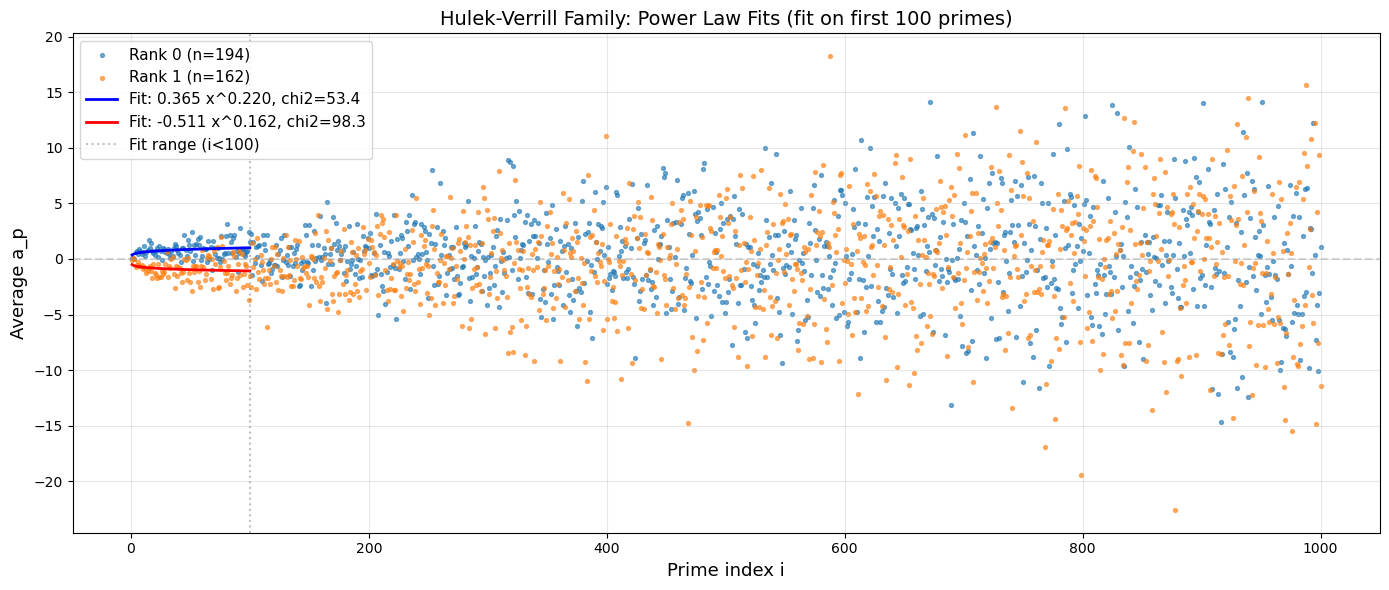


Drawing random sample from database...

Random sample rank 0 fit: 0.1969 * x^0.4335, chi2=119.91
Random sample rank 1 fit: -0.0512 * x^0.6573, chi2=155.67
Random total chi2 = 275.58

--- COMPARISON ---
HV total chi2:     151.71
Random total chi2: 275.58
HV is 1.82x cleaner than random


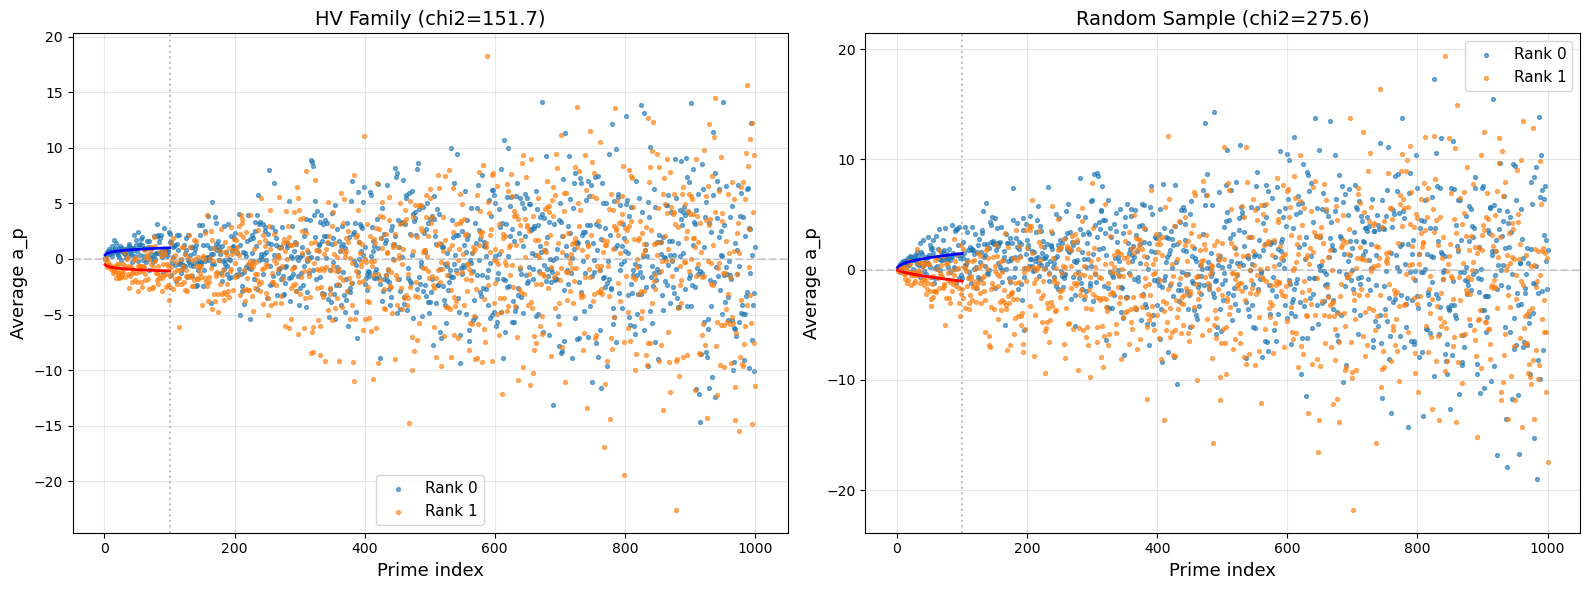

In [13]:
"""
Compare HV family murmuration vs random sample of same size
Fit with power law monomials x^alpha
"""
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.optimize import curve_fit

# Load HV data
hv_data = load('Fast_Murmuration_Search/HV_avg_aps.sobj')
rk0_avg_hv = hv_data['rk0_avg']
rk1_avg_hv = hv_data['rk1_avg']
n0_hv = hv_data['n0']
n1_hv = hv_data['n1']

print(f"HV family: {n0_hv} rank 0, {n1_hv} rank 1 curves")

# Fit with power law: A * x^alpha
def power_law(x, A, alpha):
    return A * x**alpha

# Fit only first 100 primes
N_FIT = 100
x = np.arange(1, N_FIT + 1)
rk0_fit_data = rk0_avg_hv[:N_FIT]
rk1_fit_data = rk1_avg_hv[:N_FIT]

# Fit rank 0
popt0, pcov0 = curve_fit(power_law, x, rk0_fit_data, p0=[-1, 0.5], maxfev=10000)
A0, alpha0 = popt0
fit0 = power_law(x, A0, alpha0)
residuals0 = rk0_fit_data - fit0
chi2_0 = np.sum(residuals0**2)

# Fit rank 1
popt1, pcov1 = curve_fit(power_law, x, rk1_fit_data, p0=[1, 0.5], maxfev=10000)
A1, alpha1 = popt1
fit1 = power_law(x, A1, alpha1)
residuals1 = rk1_fit_data - fit1
chi2_1 = np.sum(residuals1**2)

print(f"\nFitting first {N_FIT} primes:")
print(f"\nRank 0 fit: {A0:.4f} * x^{alpha0:.4f}")
print(f"  chi2 = {chi2_0:.2f}")
print(f"\nRank 1 fit: {A1:.4f} * x^{alpha1:.4f}")
print(f"  chi2 = {chi2_1:.2f}")
print(f"\nTotal chi2 = {chi2_0 + chi2_1:.2f}")

# Plot with fits (all primes, fit on first 100)
x_all = np.arange(1, len(rk0_avg_hv) + 1)
x_fit = np.arange(1, N_FIT + 1)

plt.figure(figsize=(14, 6))
plt.scatter(x_all, rk0_avg_hv, s=8, alpha=0.6, label=f'Rank 0 (n={n0_hv})')
plt.scatter(x_all, rk1_avg_hv, s=8, alpha=0.6, label=f'Rank 1 (n={n1_hv})')
plt.plot(x_fit, fit0, 'b-', lw=2, label=f'Fit: {A0:.3f} x^{alpha0:.3f}, chi2={chi2_0:.1f}')
plt.plot(x_fit, fit1, 'r-', lw=2, label=f'Fit: {A1:.3f} x^{alpha1:.3f}, chi2={chi2_1:.1f}')
plt.axhline(0, color='gray', ls='--', alpha=0.3)
plt.axvline(N_FIT, color='gray', ls=':', alpha=0.5, label=f'Fit range (i<{N_FIT})')
plt.xlabel('Prime index i', fontsize=13)
plt.ylabel('Average a_p', fontsize=13)
plt.title(f'Hulek-Verrill Family: Power Law Fits (fit on first {N_FIT} primes)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Fast_Murmuration_Search/HV_power_law_fit.png', dpi=150)
plt.show()

# Now compare with random sample
print("\n" + "="*60)
print("Drawing random sample from database...")

rk0_isos = [iso for iso, data in curve_db.items() if data['rank'] == 0]
rk1_isos = [iso for iso, data in curve_db.items() if data['rank'] == 1]

random.seed(int(42))
rk0_sample = random.sample(rk0_isos, n0_hv)
rk1_sample = random.sample(rk1_isos, n1_hv)

rk0_aps_rand = [curve_db[iso]['ap_list'] for iso in rk0_sample]
rk1_aps_rand = [curve_db[iso]['ap_list'] for iso in rk1_sample]

rk0_avg_rand = np.mean(rk0_aps_rand, axis=0)
rk1_avg_rand = np.mean(rk1_aps_rand, axis=0)

# Fit random sample (first N_FIT primes)
popt0_r, _ = curve_fit(power_law, x, rk0_avg_rand[:N_FIT], p0=[-1, 0.5], maxfev=10000)
A0_r, alpha0_r = popt0_r
fit0_r = power_law(x, A0_r, alpha0_r)
chi2_0_r = np.sum((rk0_avg_rand[:N_FIT] - fit0_r)**2)

popt1_r, _ = curve_fit(power_law, x, rk1_avg_rand[:N_FIT], p0=[1, 0.5], maxfev=10000)
A1_r, alpha1_r = popt1_r
fit1_r = power_law(x, A1_r, alpha1_r)
chi2_1_r = np.sum((rk1_avg_rand[:N_FIT] - fit1_r)**2)

print(f"\nRandom sample rank 0 fit: {A0_r:.4f} * x^{alpha0_r:.4f}, chi2={chi2_0_r:.2f}")
print(f"Random sample rank 1 fit: {A1_r:.4f} * x^{alpha1_r:.4f}, chi2={chi2_1_r:.2f}")
print(f"Random total chi2 = {chi2_0_r + chi2_1_r:.2f}")

print(f"\n--- COMPARISON ---")
print(f"HV total chi2:     {chi2_0 + chi2_1:.2f}")
print(f"Random total chi2: {chi2_0_r + chi2_1_r:.2f}")
print(f"HV is {(chi2_0_r + chi2_1_r)/(chi2_0 + chi2_1):.2f}x cleaner than random")

# Side by side plot (all primes)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(x_all, rk0_avg_hv, s=8, alpha=0.6, label=f'Rank 0')
axes[0].scatter(x_all, rk1_avg_hv, s=8, alpha=0.6, label=f'Rank 1')
axes[0].plot(x_fit, fit0, 'b-', lw=2)
axes[0].plot(x_fit, fit1, 'r-', lw=2)
axes[0].axhline(0, color='gray', ls='--', alpha=0.3)
axes[0].axvline(N_FIT, color='gray', ls=':', alpha=0.5)
axes[0].set_xlabel('Prime index', fontsize=13)
axes[0].set_ylabel('Average a_p', fontsize=13)
axes[0].set_title(f'HV Family (chi2={chi2_0+chi2_1:.1f})', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

x_all_rand = np.arange(1, len(rk0_avg_rand) + 1)
axes[1].scatter(x_all_rand, rk0_avg_rand, s=8, alpha=0.6, label=f'Rank 0')
axes[1].scatter(x_all_rand, rk1_avg_rand, s=8, alpha=0.6, label=f'Rank 1')
axes[1].plot(x_fit, fit0_r, 'b-', lw=2)
axes[1].plot(x_fit, fit1_r, 'r-', lw=2)
axes[1].axhline(0, color='gray', ls='--', alpha=0.3)
axes[1].axvline(N_FIT, color='gray', ls=':', alpha=0.5)
axes[1].set_xlabel('Prime index', fontsize=13)
axes[1].set_ylabel('Average a_p', fontsize=13)
axes[1].set_title(f'Random Sample (chi2={chi2_0_r+chi2_1_r:.1f})', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Fast_Murmuration_Search/HV_vs_random.png', dpi=150)
plt.show()

Discriminant Δ(φ) =
4096*(9*phi - 1)*(phi - 1)^3*phi^6

j-invariant j(φ) =
(3*phi^3 - 3*phi^2 + 9*phi - 1)^3*(3*phi - 1)^3/((9*phi - 1)*(phi - 1)^3*phi^6)

Numerical check: conductor vs φ

     φ |            N | log₁₀(N) |               Δ
--------------------------------------------------
   -10 |        10010 |     4.00 | 496111616000000
    -9 |         2460 |     3.39 | 178496151552000
    -8 |          438 |     2.64 | 57141318647808
    -7 |           14 |     1.15 | 15790581481472
    -6 |         2310 |     3.36 | 3605157642240
    -5 |         1380 |     3.14 | 635904000000
    -4 |          370 |     2.57 | 77594624000
    -3 |           84 |     1.92 | 5350883328
    -2 |          114 |     2.06 | 134479872
    -1 |           20 |     1.30 | 327680
     0 | ERROR: y^2 = x^3 - 1/3*x + 2/27 defines a singular curve
     1 | ERROR: y^2 = x^3 - 16/3*x + 128/27 defines a singular curve
     2 |           34 |     1.53 | 4456448
     3 |          156 |     2.19 | 621084672
     4 

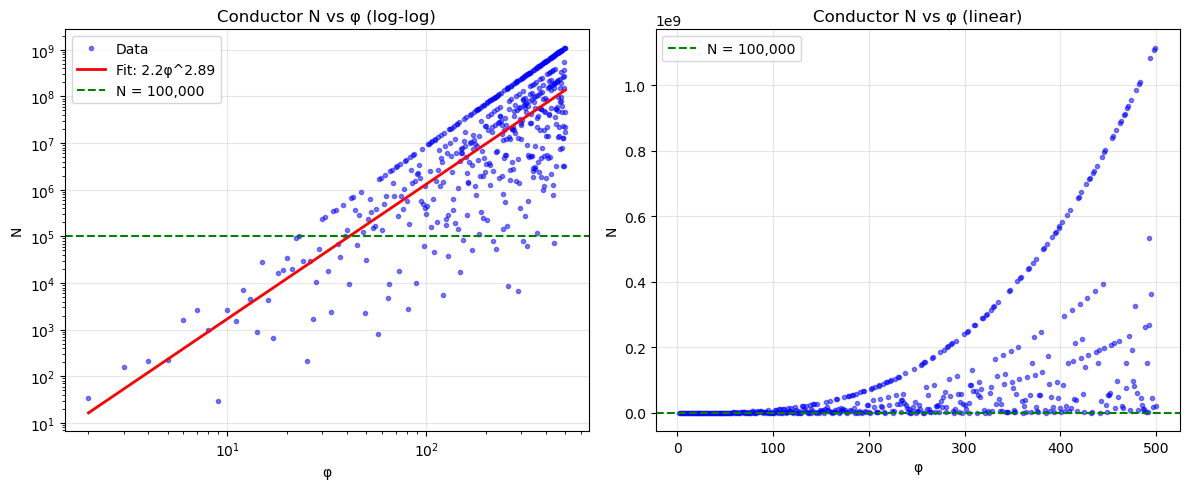

In [29]:
"""
Compute discriminant and conductor of HV family as function of φ
"""
var('phi')

# HV family coefficients (original Q(φ) form)
a = -(9*phi**4 - 12*phi**3 + 30*phi**2 - 12*phi + 1) / 3
b = -2*(27*phi**6 - 54*phi**5 - 135*phi**4 + 180*phi**3 - 99*phi**2 + 18*phi - 1) / 27

# Discriminant: Δ = -16(4a³ + 27b²)
Delta = -16 * (4*a**3 + 27*b**2)
Delta = Delta.expand()

print("Discriminant Δ(φ) =")
print(Delta.factor())

# Compute j-invariant symbolically: j = -1728 * (4a)³ / Δ
j_inv = -1728 * (4*a)**3 / Delta
j_inv = j_inv.simplify_full()
print("\nj-invariant j(φ) =")
print(j_inv.factor())

# Now check numerically for small phi values
print("\n" + "="*60)
print("Numerical check: conductor vs φ")
print("="*60)

def hv_curve(p):
    a_val = -(9*p**4 - 12*p**3 + 30*p**2 - 12*p + 1) / 3
    b_val = -2*(27*p**6 - 54*p**5 - 135*p**4 + 180*p**3 - 99*p**2 + 18*p - 1) / 27
    return EllipticCurve([0, 0, 0, a_val, b_val])

print(f"\n{'φ':>6} | {'N':>12} | {'log₁₀(N)':>8} | {'Δ':>15}")
print("-" * 50)

for p in list(range(-10, 11)) + [20, 50, 100, 200, 500, 1000]:
    try:
        E = hv_curve(p)
        N = E.conductor()
        d = E.discriminant()
        print(f"{p:>6} | {N:>12} | {float(log(N, 10)):>8.2f} | {d}")
    except Exception as e:
        print(f"{p:>6} | ERROR: {e}")

# Fit conductor growth
import numpy as np
import matplotlib.pyplot as plt

phi_vals = list(range(1, 501))
conductors = []
for p in phi_vals:
    try:
        E = hv_curve(p)
        conductors.append(int(E.conductor()))
    except:
        conductors.append(None)

# Filter valid
valid = [(p, N) for p, N in zip(phi_vals, conductors) if N is not None]
phi_arr = np.array([x[0] for x in valid])
N_arr = np.array([x[1] for x in valid])

# Log-log fit
log_phi = np.log(phi_arr)
log_N = np.log(N_arr)
coeffs = np.polyfit(log_phi, log_N, 1)
alpha = coeffs[0]
A = np.exp(coeffs[1])

print(f"\n\nPower law fit: N ≈ {A:.2f} × φ^{alpha:.2f}")
print(f"For N < 100,000, need φ < {(100000/A)**(1/alpha):.0f}")

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.loglog(phi_arr, N_arr, 'b.', alpha=0.5, label='Data')
plt.loglog(phi_arr, A * phi_arr**alpha, 'r-', lw=2, label=f'Fit: {A:.1f}φ^{alpha:.2f}')
plt.axhline(100000, color='green', ls='--', label='N = 100,000')
plt.xlabel('φ')
plt.ylabel('N')
plt.title('Conductor N vs φ (log-log)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(phi_arr, N_arr, 'b.', alpha=0.5)
plt.axhline(100000, color='green', ls='--', label='N = 100,000')
plt.xlabel('φ')
plt.ylabel('N')
plt.title('Conductor N vs φ (linear)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Fast_Murmuration_Search/HV_conductor_vs_phi.png', dpi=150)
plt.show()

Phis with N > φ^3.34: 157 out of 499

These phis:
[  2   3   4   5   6   7  10  12  15  18  19  20  22  23  30  31  34  35
  38  42  43  44  47  52  58  59  62  66  67  68  70  71  74  78  79  83
  86  87  95 102 103 106 107 110 111 115 119 123 130 131 134 138 142 143
 146 155 159 166 167 174 178 179 182 183 186 191 194 195 202 203 206 210
 211 215 218 219 222 223 227 230 231 238 247 254 255 258 259 266 267 274
 278 282 283 286 287 291 299 302 303 310 311 318 319 322 323 327 330 331
 335 346 347 355 358 359 366 367 371 374 382 383 386 391 394 395 398 399
 402 407 410 418 419 422 427 430 431 434 435 438 443 446 447 454 455 458
 462 463 466 467 470 471 474 479 482 483 494 498 499]


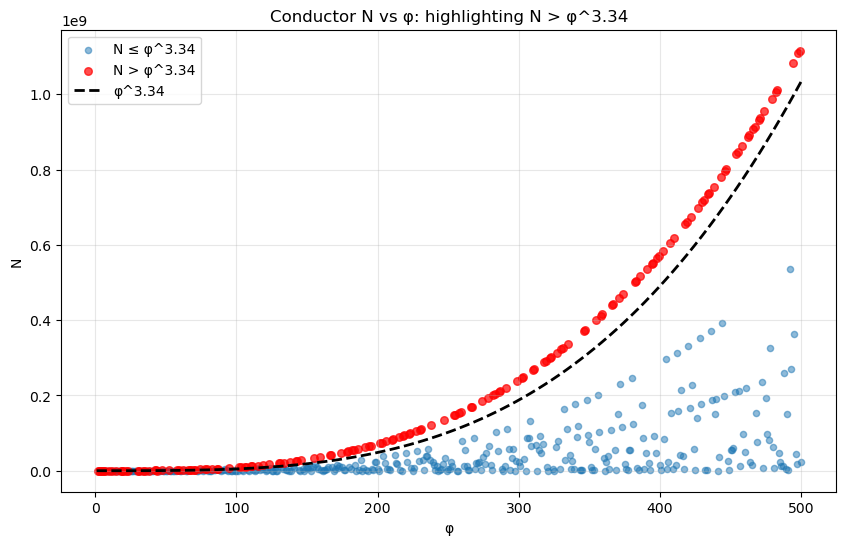

In [28]:
# Select phis where N > phi^3.34
threshold = lambda x: x**3.34

mask = N_arr > threshold(phi_arr)
phi_above = phi_arr[mask]
N_above = N_arr[mask]

print(f"Phis with N > φ^3.34: {len(phi_above)} out of {len(phi_arr)}")
print(f"\nThese phis:")
print(phi_above)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(phi_arr[~mask], N_arr[~mask], alpha=0.5, label='N ≤ φ^3.34', s=20)
plt.scatter(phi_above, N_above, alpha=0.7, c='red', label='N > φ^3.34', s=30)
plt.plot(np.linspace(1, 500, 100), threshold(np.linspace(1, 500, 100)), 'k--', lw=2, label='φ^3.34')
plt.xlabel('φ')
plt.ylabel('N')
plt.title('Conductor N vs φ: highlighting N > φ^3.34')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [1]:
"""
Complete suite for analyzing elliptic curve families and comparing to random samples
"""
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter
import random
from scipy.optimize import curve_fit

os.makedirs('Fast_Murmuration_Search', exist_ok=True)

# Load database
try:
    curve_db
    print(f"✓ curve_db loaded with {len(curve_db)} isogeny classes")
except NameError:
    print("Loading curve database...")
    curve_db = load('Curve Database (Conductor < 100 000)/curve_database_c1_to_100000.sobj')
    print(f"✓ Loaded curve_db with {len(curve_db)} isogeny classes")


# ============================================================================
# FAMILY DEFINITION AND ANALYSIS
# ============================================================================

class EllipticCurveFamily:
    """
    Define an elliptic curve family E: y^2 = x^3 + a(phi)*x + b(phi)
    
    Parameters:
    -----------
    a_coeffs : dict
        Coefficients for a(phi) as {power: coefficient}
        Example: {4: 9, 3: -12, 2: 30, 1: -12, 0: 1} for 9*phi^4 - 12*phi^3 + ...
    b_coeffs : dict
        Coefficients for b(phi) as {power: coefficient}
    name : str
        Name of the family for labeling plots/files
    """
    
    def __init__(self, a_coeffs, b_coeffs, name="CustomFamily"):
        self.a_coeffs = a_coeffs
        self.b_coeffs = b_coeffs
        self.name = name
        
        # Create polynomial ring
        R.<phi> = QQ[]
        self.a_poly = sum(coef * phi^pow for pow, coef in a_coeffs.items())
        self.b_poly = sum(coef * phi^pow for pow, coef in b_coeffs.items())
        
        print(f"Family: {name}")
        print(f"a(φ) = {self.a_poly}")
        print(f"b(φ) = {self.b_poly}")
    
    def curve(self, phi_val):
        """Compute elliptic curve for given phi value"""
        a_val = self.a_poly(phi_val)
        b_val = self.b_poly(phi_val)
        return EllipticCurve([0, 0, 0, a_val, b_val])


def get_isogeny_class(label):
    """Extract isogeny class from curve label"""
    i = len(label) - 1
    while i >= 0 and label[i].isdigit():
        i -= 1
    return label[:i+1]


def analyze_family(family, phi_range_m=(-20, 21), phi_range_n=(-20, 21), 
                   output_prefix=None):
    """
    Analyze an elliptic curve family over rational phi values
    """
    
    if output_prefix is None:
        output_prefix = family.name
    
    # Generate fraction phis: phi = m/n
    print(f"\nGenerating fraction phis from {phi_range_m} / {phi_range_n}...")
    phis = set()
    for m in range(*phi_range_m):
        for n in range(*phi_range_n):
            if n != 0:
                phis.add(QQ(m)/QQ(n))
    phis = list(phis)
    print(f"Generated {len(phis)} unique phi values")
    
    # Process curves
    print("Processing curves...")
    iso_to_phis = {}
    iso_to_data = {}
    n_hits = 0
    n_misses = 0
    
    for phi in tqdm(phis):
        try:
            E = family.curve(phi)
            iso = get_isogeny_class(E.label())
            
            # FIX: Only add to iso_to_phis if it's actually in the database
            if iso in curve_db:
                if iso not in iso_to_phis:
                    iso_to_phis[iso] = []
                    curve = curve_db[iso]
                    iso_to_data[iso] = {'rank': curve['rank'], 'aps': curve['ap_list']}
                iso_to_phis[iso].append(phi)
                n_hits += 1
            else:
                n_misses += 1
        except:
            n_misses += 1
            continue
    
    # Statistics
    n_distinct = len(iso_to_phis)
    n_redundant = n_hits - n_distinct
    efficiency = 100.0 * n_hits / len(phis) if len(phis) > 0 else 0
    
    print(f"\n{'='*60}")
    print(f"RESULTS FOR {family.name}")
    print(f"{'='*60}")
    print(f"Total phis tried: {len(phis)}")
    print(f"Hits (N < 100,000): {n_hits}")
    print(f"Misses (N >= 100,000 or singular): {n_misses}")
    print(f"Efficiency: {efficiency:.1f}%")
    print(f"\nDistinct isogeny classes: {n_distinct}")
    print(f"Redundant hits (same iso class): {n_redundant}")
    
    # Multiplicity distribution
    multiplicities = [len(v) for v in iso_to_phis.values()]
    mult_counts = Counter(multiplicities)
    print(f"\nMultiplicity distribution:")
    for m in sorted(mult_counts.keys()):
        print(f"  {m}x: {mult_counts[m]} isogeny classes")
    
    # Top multiplicities
    print(f"\nTop 10 highest multiplicity isogeny classes:")
    sorted_iso = sorted(iso_to_phis.items(), key=lambda x: len(x[1]), reverse=True)[:10]
    for iso, phi_list in sorted_iso:
        print(f"  {iso}: {len(phi_list)} phis → {phi_list[:5]}{'...' if len(phi_list) > 5 else ''}")
    
    # Extract aps by rank
    rk0_aps, rk1_aps = [], []
    for iso, data in iso_to_data.items():
        if data['rank'] == 0:
            rk0_aps.append(data['aps'])
        elif data['rank'] == 1:
            rk1_aps.append(data['aps'])
    
    print(f"\nRank 0: {len(rk0_aps)} curves")
    print(f"Rank 1: {len(rk1_aps)} curves")
    
    # Need at least a few curves for meaningful analysis
    min_curves_needed = 10
    if len(rk0_aps) + len(rk1_aps) < min_curves_needed:
        print(f"\n⚠ Warning: Only {len(rk0_aps) + len(rk1_aps)} curves found.")
        print(f"Need at least {min_curves_needed} for meaningful murmuration analysis.")
        print("Skipping averaging and plotting.")
        return None
    
    # Average
    rk0_avg = np.mean(rk0_aps, axis=0) if len(rk0_aps) > 0 else np.array([])
    rk1_avg = np.mean(rk1_aps, axis=0) if len(rk1_aps) > 0 else np.array([])
    
    # Save
    save_path = f'Fast_Murmuration_Search/{output_prefix}_avg_aps.sobj'
    save({'rk0_avg': rk0_avg, 'rk1_avg': rk1_avg, 
          'n0': len(rk0_aps), 'n1': len(rk1_aps),
          'family_name': family.name,
          'a_coeffs': family.a_coeffs,
          'b_coeffs': family.b_coeffs}, save_path)
    print(f"\nSaved to {save_path}")
    
    # Plot
    plt.figure(figsize=(14, 7))
    if len(rk0_aps) > 0:
        plt.scatter(range(len(rk0_avg)), rk0_avg, s=8, alpha=0.7, 
                   label=f'Rank 0 (n={len(rk0_aps)})')
    if len(rk1_aps) > 0:
        plt.scatter(range(len(rk1_avg)), rk1_avg, s=8, alpha=0.7, 
                   label=f'Rank 1 (n={len(rk1_aps)})')
    plt.axhline(0, color='gray', ls='--', alpha=0.3)
    plt.xlabel('Prime index $i$', fontsize=13)
    plt.ylabel(r'Average $a_{p_i}$', fontsize=13)
    plt.title(f'{family.name}: Average Frobenius Traces by Rank', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plot_path = f'Fast_Murmuration_Search/{output_prefix}_avg_aps.png'
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"Plot saved to {plot_path}")
    
    return {
        'iso_to_phis': iso_to_phis,
        'iso_to_data': iso_to_data,
        'rk0_avg': rk0_avg,
        'rk1_avg': rk1_avg,
        'stats': {
            'n_phis': len(phis),
            'n_hits': n_hits,
            'n_misses': n_misses,
            'n_distinct': n_distinct,
            'efficiency': efficiency
        }
    }


# ============================================================================
# COMPARISON TO RANDOM SAMPLES
# ============================================================================

def power_law(x, A, alpha):
    """Power law function: A * x^alpha"""
    return A * x**alpha


def compare_family_to_random(family_name, data_path=None, n_fit=100, seed=42,
                             output_dir='Fast_Murmuration_Search'):
    """
    Compare a family's murmuration to a random sample of the same size
    
    Parameters:
    -----------
    family_name : str
        Name of the family (used for loading data if data_path not provided)
    data_path : str, optional
        Path to the saved .sobj file. If None, uses family_name to construct path
    n_fit : int
        Number of first primes to use for fitting
    seed : int
        Random seed for reproducibility
    output_dir : str
        Directory for saving plots
    """
    
    # Load family data
    if data_path is None:
        data_path = f'{output_dir}/{family_name}_avg_aps.sobj'
    
    print(f"Loading data from {data_path}...")
    family_data = load(data_path)
    
    rk0_avg_fam = family_data['rk0_avg']
    rk1_avg_fam = family_data['rk1_avg']
    n0_fam = family_data['n0']
    n1_fam = family_data['n1']
    
    display_name = family_data.get('family_name', family_name)
    
    print(f"\n{display_name} family: {n0_fam} rank 0, {n1_fam} rank 1 curves")
    
    if n0_fam == 0 and n1_fam == 0:
        print("No curves found with rank 0 or 1. Cannot perform comparison.")
        return None
    
    # Prepare fitting data
    N_FIT = min(int(n_fit), len(rk0_avg_fam), len(rk1_avg_fam))
    x = np.arange(1, N_FIT + 1)
    
    # Fit family data
    print(f"\nFitting first {N_FIT} primes for {display_name}...")
    
    results = {}
    
    # Rank 0 fit (if available)
    if n0_fam > 0 and len(rk0_avg_fam) >= N_FIT:
        rk0_fit_data = rk0_avg_fam[:N_FIT]
        try:
            popt0, pcov0 = curve_fit(power_law, x, rk0_fit_data, p0=[-1, 0.5], maxfev=10000)
            A0, alpha0 = popt0
            fit0 = power_law(x, A0, alpha0)
            residuals0 = rk0_fit_data - fit0
            chi2_0 = np.sum(residuals0**2)
            
            print(f"\nRank 0 fit: {A0:.4f} * x^{alpha0:.4f}")
            print(f"  chi2 = {chi2_0:.2f}")
            
            results['rk0'] = {
                'A': A0, 'alpha': alpha0, 'chi2': chi2_0,
                'fit': fit0, 'popt': popt0
            }
        except Exception as e:
            print(f"Rank 0 fit failed: {e}")
            results['rk0'] = None
    else:
        results['rk0'] = None
    
    # Rank 1 fit (if available)
    if n1_fam > 0 and len(rk1_avg_fam) >= N_FIT:
        rk1_fit_data = rk1_avg_fam[:N_FIT]
        try:
            popt1, pcov1 = curve_fit(power_law, x, rk1_fit_data, p0=[1, 0.5], maxfev=10000)
            A1, alpha1 = popt1
            fit1 = power_law(x, A1, alpha1)
            residuals1 = rk1_fit_data - fit1
            chi2_1 = np.sum(residuals1**2)
            
            print(f"\nRank 1 fit: {A1:.4f} * x^{alpha1:.4f}")
            print(f"  chi2 = {chi2_1:.2f}")
            
            results['rk1'] = {
                'A': A1, 'alpha': alpha1, 'chi2': chi2_1,
                'fit': fit1, 'popt': popt1
            }
        except Exception as e:
            print(f"Rank 1 fit failed: {e}")
            results['rk1'] = None
    else:
        results['rk1'] = None
    
    # Total chi2 for family
    chi2_fam_total = 0
    if results['rk0'] is not None:
        chi2_fam_total += results['rk0']['chi2']
    if results['rk1'] is not None:
        chi2_fam_total += results['rk1']['chi2']
    
    print(f"\nTotal chi2 for {display_name} = {chi2_fam_total:.2f}")
    
    # Random sample comparison
    print("\n" + "="*60)
    print("Drawing random sample from database...")
    
    rk0_isos = [iso for iso, data in curve_db.items() if data['rank'] == 0]
    rk1_isos = [iso for iso, data in curve_db.items() if data['rank'] == 1]
    
    random.seed(int(seed))  # FIX: Convert to Python int
    
    # Sample random curves
    rk0_aps_rand = []
    rk1_aps_rand = []
    rk0_avg_rand = np.array([])
    rk1_avg_rand = np.array([])
    
    if n0_fam > 0:
        rk0_sample = random.sample(rk0_isos, n0_fam)
        rk0_aps_rand = [curve_db[iso]['ap_list'] for iso in rk0_sample]
        rk0_avg_rand = np.mean(rk0_aps_rand, axis=0)
    
    if n1_fam > 0:
        rk1_sample = random.sample(rk1_isos, n1_fam)
        rk1_aps_rand = [curve_db[iso]['ap_list'] for iso in rk1_sample]
        rk1_avg_rand = np.mean(rk1_aps_rand, axis=0)
    
    # Fit random sample
    print(f"\nFitting random sample (first {N_FIT} primes)...")
    
    results_rand = {}
    
    # Rank 0 random fit
    if n0_fam > 0 and len(rk0_avg_rand) >= N_FIT:
        try:
            popt0_r, _ = curve_fit(power_law, x, rk0_avg_rand[:N_FIT], p0=[-1, 0.5], maxfev=10000)
            A0_r, alpha0_r = popt0_r
            fit0_r = power_law(x, A0_r, alpha0_r)
            chi2_0_r = np.sum((rk0_avg_rand[:N_FIT] - fit0_r)**2)
            
            print(f"Random sample rank 0 fit: {A0_r:.4f} * x^{alpha0_r:.4f}, chi2={chi2_0_r:.2f}")
            
            results_rand['rk0'] = {
                'A': A0_r, 'alpha': alpha0_r, 'chi2': chi2_0_r,
                'fit': fit0_r, 'popt': popt0_r
            }
        except Exception as e:
            print(f"Random rank 0 fit failed: {e}")
            results_rand['rk0'] = None
    else:
        results_rand['rk0'] = None
    
    # Rank 1 random fit
    if n1_fam > 0 and len(rk1_avg_rand) >= N_FIT:
        try:
            popt1_r, _ = curve_fit(power_law, x, rk1_avg_rand[:N_FIT], p0=[1, 0.5], maxfev=10000)
            A1_r, alpha1_r = popt1_r
            fit1_r = power_law(x, A1_r, alpha1_r)
            chi2_1_r = np.sum((rk1_avg_rand[:N_FIT] - fit1_r)**2)
            
            print(f"Random sample rank 1 fit: {A1_r:.4f} * x^{alpha1_r:.4f}, chi2={chi2_1_r:.2f}")
            
            results_rand['rk1'] = {
                'A': A1_r, 'alpha': alpha1_r, 'chi2': chi2_1_r,
                'fit': fit1_r, 'popt': popt1_r
            }
        except Exception as e:
            print(f"Random rank 1 fit failed: {e}")
            results_rand['rk1'] = None
    else:
        results_rand['rk1'] = None
    
    # Total chi2 for random
    chi2_rand_total = 0
    if results_rand['rk0'] is not None:
        chi2_rand_total += results_rand['rk0']['chi2']
    if results_rand['rk1'] is not None:
        chi2_rand_total += results_rand['rk1']['chi2']
    
    print(f"Random total chi2 = {chi2_rand_total:.2f}")
    
    # Comparison
    print(f"\n{'='*60}")
    print(f"--- COMPARISON ---")
    print(f"{display_name} total chi2:     {chi2_fam_total:.2f}")
    print(f"Random total chi2: {chi2_rand_total:.2f}")
    
    if chi2_fam_total > 0:
        ratio = chi2_rand_total / chi2_fam_total
        print(f"{display_name} is {ratio:.2f}x cleaner than random")
    else:
        ratio = None
        print("Cannot compute ratio (family chi2 is 0)")
    
    # ========================================================================
    # PLOTTING
    # ========================================================================
    
    # Plot 1: Family data with fits
    x_all = np.arange(1, max(len(rk0_avg_fam), len(rk1_avg_fam)) + 1)
    x_fit = np.arange(1, N_FIT + 1)
    
    plt.figure(figsize=(14, 6))
    
    if n0_fam > 0:
        plt.scatter(x_all[:len(rk0_avg_fam)], rk0_avg_fam, s=8, alpha=0.6, 
                   label=f'Rank 0 (n={n0_fam})')
        if results['rk0'] is not None:
            plt.plot(x_fit, results['rk0']['fit'], 'b-', lw=2, 
                    label=f"Fit: {results['rk0']['A']:.3f} x^{results['rk0']['alpha']:.3f}, chi2={results['rk0']['chi2']:.1f}")
    
    if n1_fam > 0:
        plt.scatter(x_all[:len(rk1_avg_fam)], rk1_avg_fam, s=8, alpha=0.6, 
                   label=f'Rank 1 (n={n1_fam})')
        if results['rk1'] is not None:
            plt.plot(x_fit, results['rk1']['fit'], 'r-', lw=2, 
                    label=f"Fit: {results['rk1']['A']:.3f} x^{results['rk1']['alpha']:.3f}, chi2={results['rk1']['chi2']:.1f}")
    
    plt.axhline(0, color='gray', ls='--', alpha=0.3)
    plt.axvline(N_FIT, color='gray', ls=':', alpha=0.5, label=f'Fit range (i<{N_FIT})')
    plt.xlabel('Prime index i', fontsize=13)
    plt.ylabel('Average a_p', fontsize=13)
    plt.title(f'{display_name} Family: Power Law Fits (fit on first {N_FIT} primes)', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plot_path1 = f'{output_dir}/{family_name}_power_law_fit.png'
    plt.savefig(plot_path1, dpi=150)
    print(f"\nSaved power law fit plot to {plot_path1}")
    plt.show()
    
    # Plot 2: Side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: Family
    if n0_fam > 0:
        axes[0].scatter(x_all[:len(rk0_avg_fam)], rk0_avg_fam, s=8, alpha=0.6, label='Rank 0')
        if results['rk0'] is not None:
            axes[0].plot(x_fit, results['rk0']['fit'], 'b-', lw=2)
    
    if n1_fam > 0:
        axes[0].scatter(x_all[:len(rk1_avg_fam)], rk1_avg_fam, s=8, alpha=0.6, label='Rank 1')
        if results['rk1'] is not None:
            axes[0].plot(x_fit, results['rk1']['fit'], 'r-', lw=2)
    
    axes[0].axhline(0, color='gray', ls='--', alpha=0.3)
    axes[0].axvline(N_FIT, color='gray', ls=':', alpha=0.5)
    axes[0].set_xlabel('Prime index', fontsize=13)
    axes[0].set_ylabel('Average a_p', fontsize=13)
    axes[0].set_title(f'{display_name} Family (chi2={chi2_fam_total:.1f})', fontsize=14)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Right: Random
    x_all_rand = np.arange(1, max(len(rk0_avg_rand) if n0_fam > 0 else 0, 
                                   len(rk1_avg_rand) if n1_fam > 0 else 0) + 1)
    
    if n0_fam > 0:
        axes[1].scatter(x_all_rand[:len(rk0_avg_rand)], rk0_avg_rand, s=8, alpha=0.6, label='Rank 0')
        if results_rand['rk0'] is not None:
            axes[1].plot(x_fit, results_rand['rk0']['fit'], 'b-', lw=2)
    
    if n1_fam > 0:
        axes[1].scatter(x_all_rand[:len(rk1_avg_rand)], rk1_avg_rand, s=8, alpha=0.6, label='Rank 1')
        if results_rand['rk1'] is not None:
            axes[1].plot(x_fit, results_rand['rk1']['fit'], 'r-', lw=2)
    
    axes[1].axhline(0, color='gray', ls='--', alpha=0.3)
    axes[1].axvline(N_FIT, color='gray', ls=':', alpha=0.5)
    axes[1].set_xlabel('Prime index', fontsize=13)
    axes[1].set_ylabel('Average a_p', fontsize=13)
    axes[1].set_title(f'Random Sample (chi2={chi2_rand_total:.1f})', fontsize=14)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    plot_path2 = f'{output_dir}/{family_name}_vs_random.png'
    plt.savefig(plot_path2, dpi=150)
    print(f"Saved comparison plot to {plot_path2}")
    plt.show()
    
    # Return summary
    return {
        'family_name': display_name,
        'family_results': results,
        'random_results': results_rand,
        'family_chi2': chi2_fam_total,
        'random_chi2': chi2_rand_total,
        'improvement_ratio': ratio,
        'n0': n0_fam,
        'n1': n1_fam,
        'n_fit': N_FIT
    }


# ============================================================================
# EXAMPLE USAGE
# ============================================================================

print("\n" + "="*60)
print("READY TO USE!")
print("="*60)
print("\nExample 1: Hulek-Verrill family")
print("-" * 40)

Loading curve database...
✓ Loaded curve_db with 437226 isogeny classes

READY TO USE!

Example 1: Hulek-Verrill family
----------------------------------------


Family: Hulek-Verrill
a(φ) = -243*phi^4 + 324*phi^3 - 810*phi^2 + 324*phi - 27
b(φ) = -1458*phi^6 + 2916*phi^5 + 7290*phi^4 - 9720*phi^3 + 5346*phi^2 - 972*phi + 54

STEP 1: ANALYZING HULEK-VERRILL FAMILY

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [00:33<00:00, 15.17it/s]



RESULTS FOR Hulek-Verrill
Total phis tried: 511
Hits (N < 100,000): 427
Misses (N >= 100,000 or singular): 84
Efficiency: 83.6%

Distinct isogeny classes: 363
Redundant hits (same iso class): 64

Multiplicity distribution:
  1x: 308 isogeny classes
  2x: 49 isogeny classes
  3x: 4 isogeny classes
  4x: 1 isogeny classes
  5x: 1 isogeny classes

Top 10 highest multiplicity isogeny classes:
  30a: 5 phis → [9, -3/5, 1/4, 3/2, 1/10]
  14a: 4 phis → [1/8, -1/7, 1/2, -7]
  210a: 3 phis → [4, -2/7, 6/5]
  4290bb: 3 phis → [16, -12/13, 20/11]
  126a: 3 phis → [-7/9, 2/9, 8/9]
  210b: 3 phis → [1/16, 15/7, -5/4]
  34a: 2 phis → [2, 1/17]
  156b: 2 phis → [3, 1/13]
  220a: 2 phis → [5, 1/11]
  910j: 2 phis → [14, 8/7]

Rank 0: 194 curves
Rank 1: 162 curves

Saved to Fast_Murmuration_Search/Hulek_Verrill_avg_aps.sobj


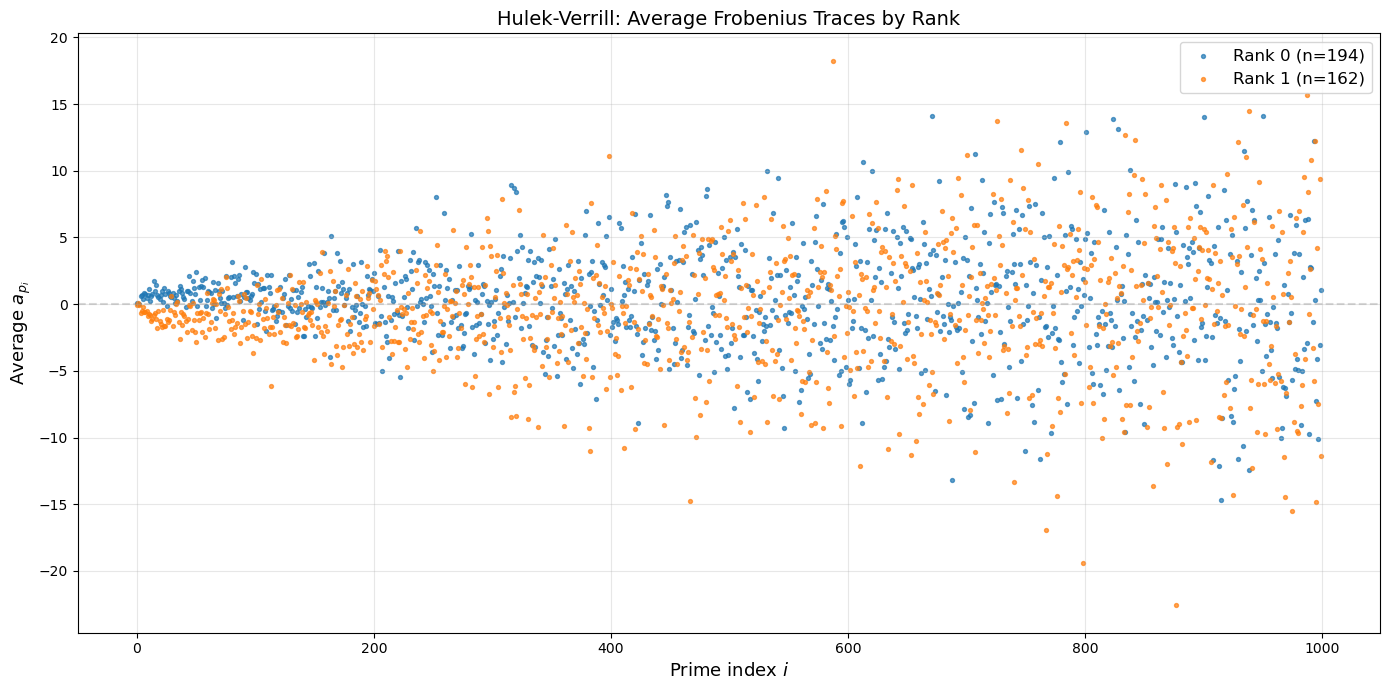

Plot saved to Fast_Murmuration_Search/Hulek_Verrill_avg_aps.png

STEP 2: COMPARING TO RANDOM SAMPLES
Loading data from Fast_Murmuration_Search/Hulek_Verrill_avg_aps.sobj...

Hulek-Verrill family: 194 rank 0, 162 rank 1 curves

Fitting first 100 primes for Hulek-Verrill...

Rank 0 fit: 0.3649 * x^0.2199
  chi2 = 53.40

Rank 1 fit: -0.5106 * x^0.1622
  chi2 = 98.31

Total chi2 for Hulek-Verrill = 151.71

Drawing random sample from database...

Fitting random sample (first 100 primes)...
Random sample rank 0 fit: 0.1969 * x^0.4335, chi2=119.91
Random sample rank 1 fit: -0.0512 * x^0.6573, chi2=155.67
Random total chi2 = 275.58

--- COMPARISON ---
Hulek-Verrill total chi2:     151.71
Random total chi2: 275.58
Hulek-Verrill is 1.82x cleaner than random

Saved power law fit plot to Fast_Murmuration_Search/Hulek_Verrill_power_law_fit.png


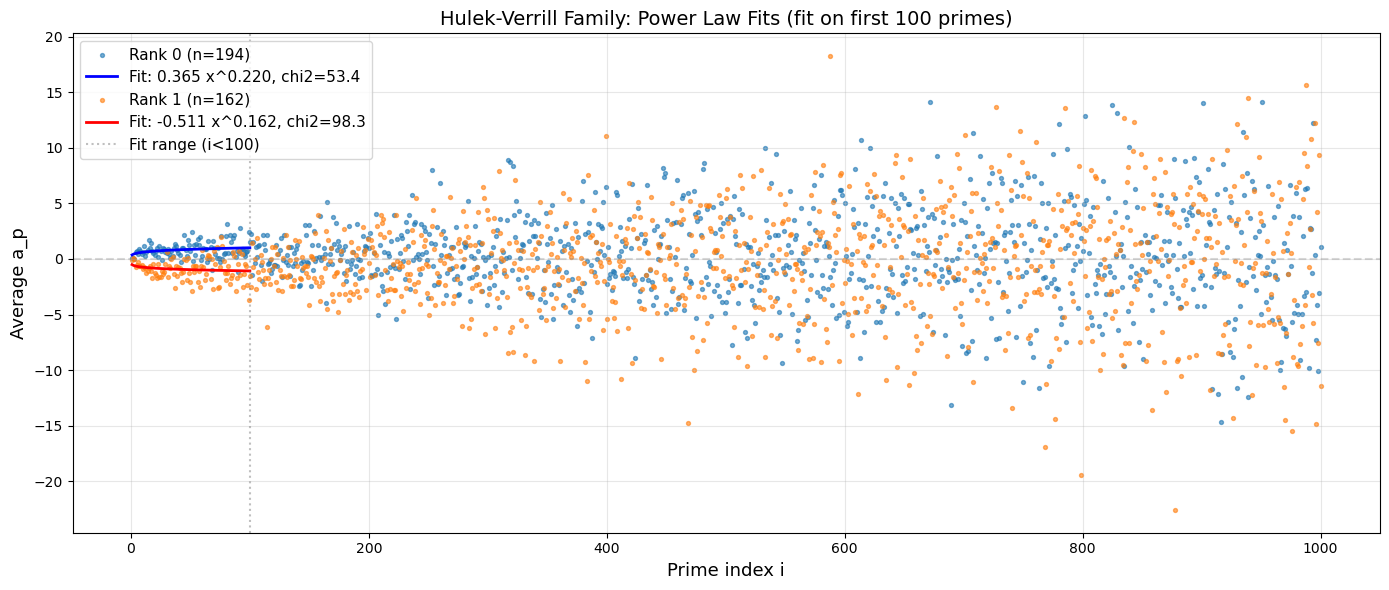

Saved comparison plot to Fast_Murmuration_Search/Hulek_Verrill_vs_random.png


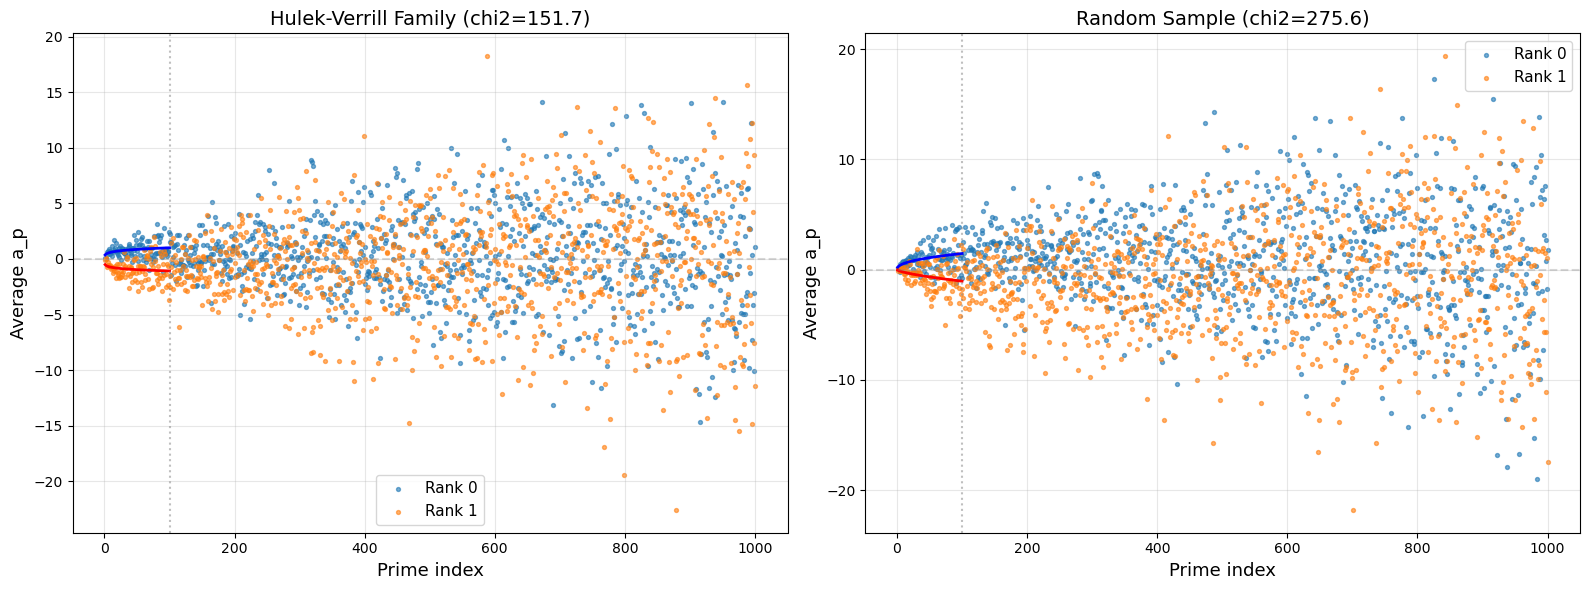


FINAL SUMMARY
Family: Hulek-Verrill
Curves found: 194 rank 0, 162 rank 1

Family chi² = 151.71
Random chi² = 275.58

HV family is 1.82x cleaner than random!


In [2]:
# ============================================================================
# HULEK-VERRILL FAMILY ANALYSIS
# ============================================================================

# Define the HV family coefficients
# a(φ) = -27 * (9φ^4 - 12φ^3 + 30φ^2 - 12φ + 1)
#      = -243φ^4 + 324φ^3 - 810φ^2 + 324φ - 27
hv_a_coeffs = {
    4: -243,
    3: 324,
    2: -810,
    1: 324,
    0: -27
}

# b(φ) = -54 * (27φ^6 - 54φ^5 - 135φ^4 + 180φ^3 - 99φ^2 + 18φ - 1)
#      = -1458φ^6 + 2916φ^5 + 7290φ^4 - 9720φ^3 + 5346φ^2 - 972φ + 54
hv_b_coeffs = {
    6: -1458,
    5: 2916,
    4: 7290,
    3: -9720,
    2: 5346,
    1: -972,
    0: 54
}

# Create the HV family object
hv_family = EllipticCurveFamily(
    a_coeffs=hv_a_coeffs,
    b_coeffs=hv_b_coeffs,
    name="Hulek-Verrill"
)

# Step 1: Analyze the family
print("\n" + "="*60)
print("STEP 1: ANALYZING HULEK-VERRILL FAMILY")
print("="*60)

hv_results = analyze_family(
    hv_family,
    phi_range_m=(-20, 21),   # φ = m/n with -20 ≤ m ≤ 20
    phi_range_n=(-20, 21),   # and -20 ≤ n ≤ 20 (n ≠ 0)
    output_prefix="Hulek_Verrill"
)

# Step 2: Compare to random samples
print("\n" + "="*60)
print("STEP 2: COMPARING TO RANDOM SAMPLES")
print("="*60)

comparison = compare_family_to_random(
    family_name="Hulek_Verrill",
    n_fit=100,      # Fit first 100 primes
    seed=42,        # For reproducibility
    output_dir='Fast_Murmuration_Search'
)

# Step 3: Display summary
if comparison is not None:
    print("\n" + "="*60)
    print("FINAL SUMMARY")
    print("="*60)
    print(f"Family: {comparison['family_name']}")
    print(f"Curves found: {comparison['n0']} rank 0, {comparison['n1']} rank 1")
    print(f"\nFamily chi² = {comparison['family_chi2']:.2f}")
    print(f"Random chi² = {comparison['random_chi2']:.2f}")
    if comparison['improvement_ratio'] is not None:
        print(f"\nHV family is {comparison['improvement_ratio']:.2f}x cleaner than random!")

In [2]:
# ============================================================================
# ROBUST ANALYSIS WITH FULL ERROR HANDLING
# ============================================================================

def run_family_analysis(family_name, a_coeffs, b_coeffs, 
                        phi_range_m=(-20, 21), phi_range_n=(-20, 21),
                        n_fit=100, seed=42):
    """
    Run complete family analysis with comprehensive error handling
    """
    
    # Create family
    try:
        my_family = EllipticCurveFamily(
            a_coeffs=a_coeffs,
            b_coeffs=b_coeffs,
            name=family_name
        )
    except Exception as e:
        print(f"❌ Failed to create family: {e}")
        return None
    
    # Analyze
    print("\n" + "="*60)
    print(f"STEP 1: ANALYZING {family_name} FAMILY")
    print("="*60)
    
    try:
        results = analyze_family(
            my_family,
            phi_range_m=phi_range_m,
            phi_range_n=phi_range_n,
            output_prefix=family_name.replace(" ", "_")
        )
    except Exception as e:
        print(f"❌ Analysis failed: {e}")
        return None
    
    # Check results
    if results is None:
        print("\n" + "="*60)
        print("❌ NO CURVES FOUND")
        print("="*60)
        print("Try:")
        print(f"  • Expanding φ ranges beyond {phi_range_m} / {phi_range_n}")
        print("  • Verifying coefficient formulas")
        print("  • Using different parameter values")
        return None
    
    if results['stats']['n_distinct'] < 10:
        print(f"\n⚠️  Warning: Only {results['stats']['n_distinct']} curves found.")
        print("Murmuration analysis may not be statistically meaningful.")
    
    # Compare to random
    print("\n" + "="*60)
    print("STEP 2: COMPARING TO RANDOM SAMPLES")
    print("="*60)
    
    try:
        comparison = compare_family_to_random(
            family_name=family_name.replace(" ", "_"),
            n_fit=n_fit,
            seed=seed,
            output_dir='Fast_Murmuration_Search'
        )
    except FileNotFoundError:
        print("❌ Data file not found. Analysis may have failed to save results.")
        return results
    except Exception as e:
        print(f"❌ Comparison failed: {e}")
        return results
    
    # Summary
    if comparison is not None:
        print("\n" + "="*60)
        print("✓ SUCCESS - FINAL SUMMARY")
        print("="*60)
        print(f"Family: {comparison['family_name']}")
        print(f"Curves: {comparison['n0']} rank 0, {comparison['n1']} rank 1")
        print(f"Family chi² = {comparison['family_chi2']:.2f}")
        print(f"Random chi² = {comparison['random_chi2']:.2f}")
        if comparison['improvement_ratio'] is not None:
            print(f"\n🎯 {family_name} is {comparison['improvement_ratio']:.2f}x cleaner!")
    
    return {'results': results, 'comparison': comparison}

In [5]:
output = run_family_analysis(
    family_name="HV_modified",
    a_coeffs={   4: -245,
    3: 324,
    2: -810,
    1: 324,
    0: -27},
    b_coeffs={6: -1458,
    5: 2916,
    4: 7290,
    3: -9720,
    2: 5346,
    1: -972,
    0: 54},
    phi_range_m=(-20, 21),
    phi_range_n=(-20, 21),
    n_fit=100,
    seed=42
)

Family: HV_modified
a(φ) = -245*phi^4 + 324*phi^3 - 810*phi^2 + 324*phi - 27
b(φ) = -1458*phi^6 + 2916*phi^5 + 7290*phi^4 - 9720*phi^3 + 5346*phi^2 - 972*phi + 54

STEP 1: ANALYZING HV_modified FAMILY

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [01:30<00:00,  5.62it/s]


RESULTS FOR HV_modified
Total phis tried: 511
Hits (N < 100,000): 0
Misses (N >= 100,000 or singular): 511
Efficiency: 0.0%

Distinct isogeny classes: 0
Redundant hits (same iso class): 0

Multiplicity distribution:

Top 10 highest multiplicity isogeny classes:

Rank 0: 0 curves
Rank 1: 0 curves

⚠ Warning: Only 0 curves found.
Need at least 10 for meaningful murmuration analysis.
Skipping averaging and plotting.

❌ NO CURVES FOUND
Try:
  • Expanding φ ranges beyond (-20, 21) / (-20, 21)
  • Verifying coefficient formulas
  • Using different parameter values


Family: HV
a(φ) = -243*phi^4 + 324*phi^3 - 810*phi^2 + 324*phi - 27
b(φ) = -1458*phi^6 + 2916*phi^5 + 7290*phi^4 - 9720*phi^3 + 5346*phi^2 - 972*phi + 54

STEP 1: ANALYZING HV FAMILY

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [01:35<00:00,  5.35it/s]



RESULTS FOR HV
Total phis tried: 511
Hits (N < 100,000): 427
Misses (N >= 100,000 or singular): 84
Efficiency: 83.6%

Distinct isogeny classes: 363
Redundant hits (same iso class): 64

Multiplicity distribution:
  1x: 308 isogeny classes
  2x: 49 isogeny classes
  3x: 4 isogeny classes
  4x: 1 isogeny classes
  5x: 1 isogeny classes

Top 10 highest multiplicity isogeny classes:
  30a: 5 phis → [9, -3/5, 1/4, 3/2, 1/10]
  14a: 4 phis → [1/8, -1/7, 1/2, -7]
  210a: 3 phis → [4, -2/7, 6/5]
  4290bb: 3 phis → [16, -12/13, 20/11]
  126a: 3 phis → [-7/9, 2/9, 8/9]
  210b: 3 phis → [1/16, 15/7, -5/4]
  34a: 2 phis → [2, 1/17]
  156b: 2 phis → [3, 1/13]
  220a: 2 phis → [5, 1/11]
  910j: 2 phis → [14, 8/7]

Rank 0: 194 curves
Rank 1: 162 curves

Saved to Fast_Murmuration_Search/HV_avg_aps.sobj


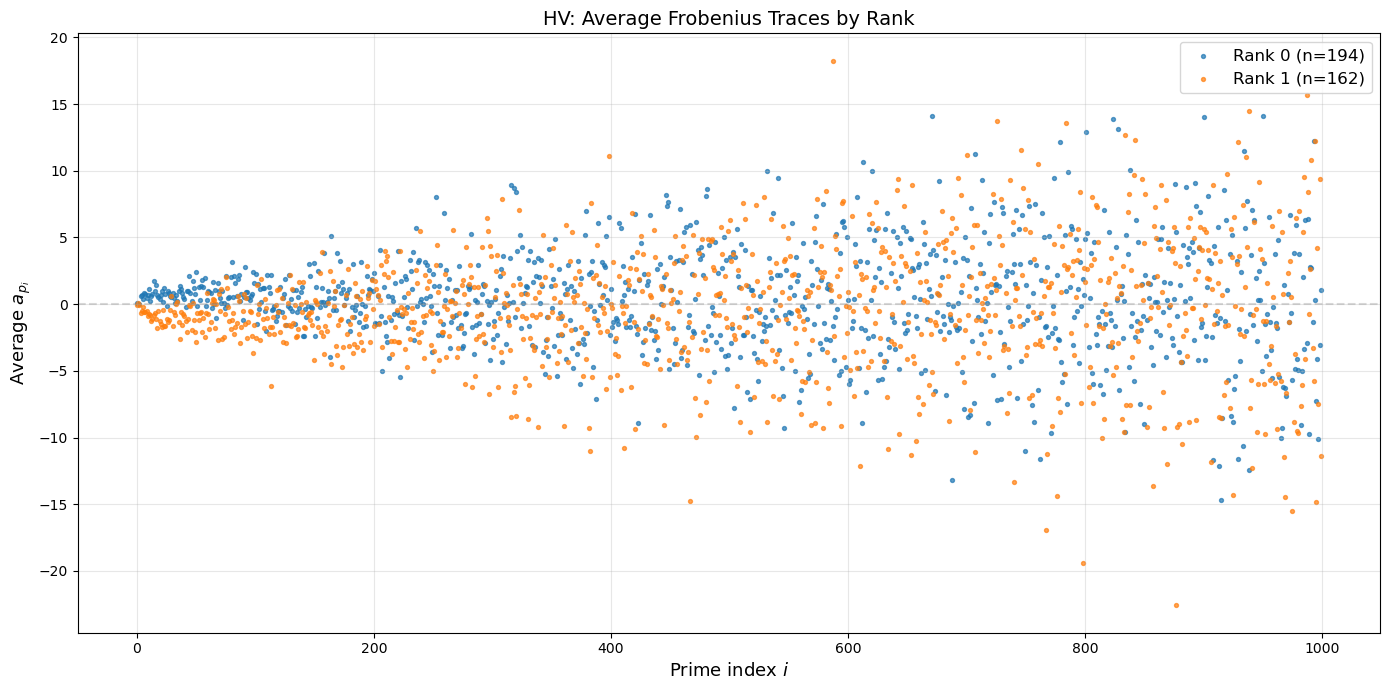

Plot saved to Fast_Murmuration_Search/HV_avg_aps.png

STEP 2: COMPARING TO RANDOM SAMPLES
Loading data from Fast_Murmuration_Search/HV_avg_aps.sobj...

HV family: 194 rank 0, 162 rank 1 curves

Fitting first 100 primes for HV...

Rank 0 fit: 0.3649 * x^0.2199
  chi2 = 53.40

Rank 1 fit: -0.5106 * x^0.1622
  chi2 = 98.31

Total chi2 for HV = 151.71

Drawing random sample from database...

Fitting random sample (first 100 primes)...
Random sample rank 0 fit: 0.1969 * x^0.4335, chi2=119.91
Random sample rank 1 fit: -0.0512 * x^0.6573, chi2=155.67
Random total chi2 = 275.58

--- COMPARISON ---
HV total chi2:     151.71
Random total chi2: 275.58
HV is 1.82x cleaner than random

Saved power law fit plot to Fast_Murmuration_Search/HV_power_law_fit.png


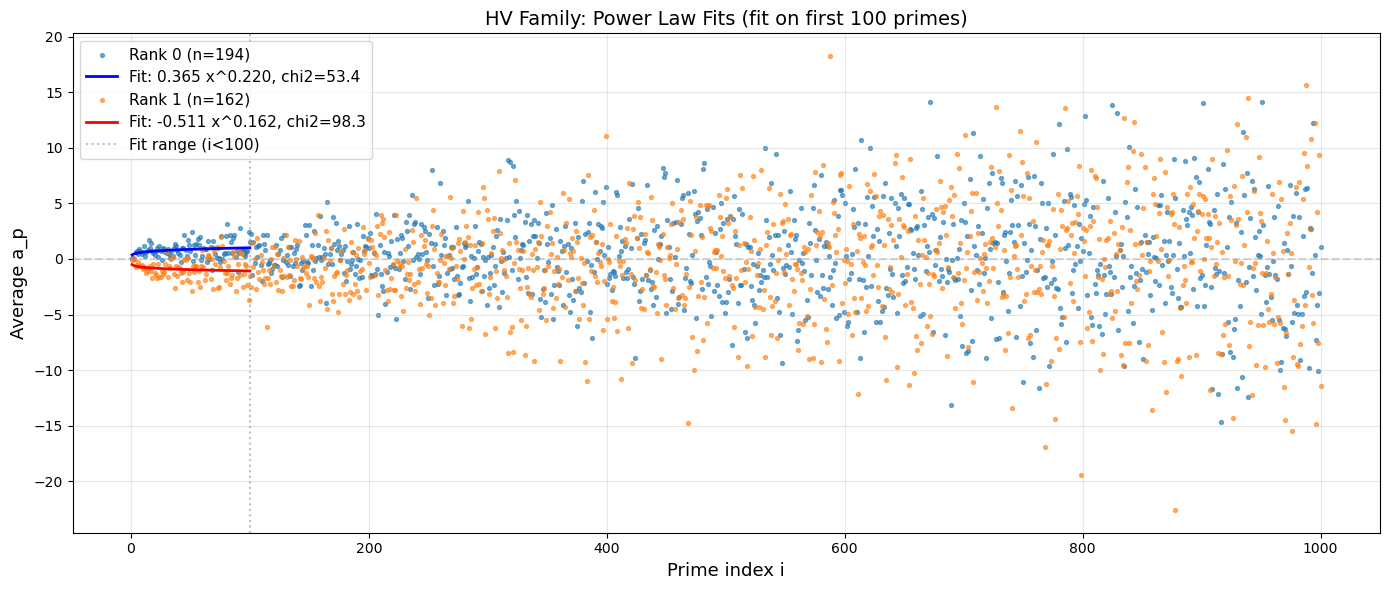

Saved comparison plot to Fast_Murmuration_Search/HV_vs_random.png


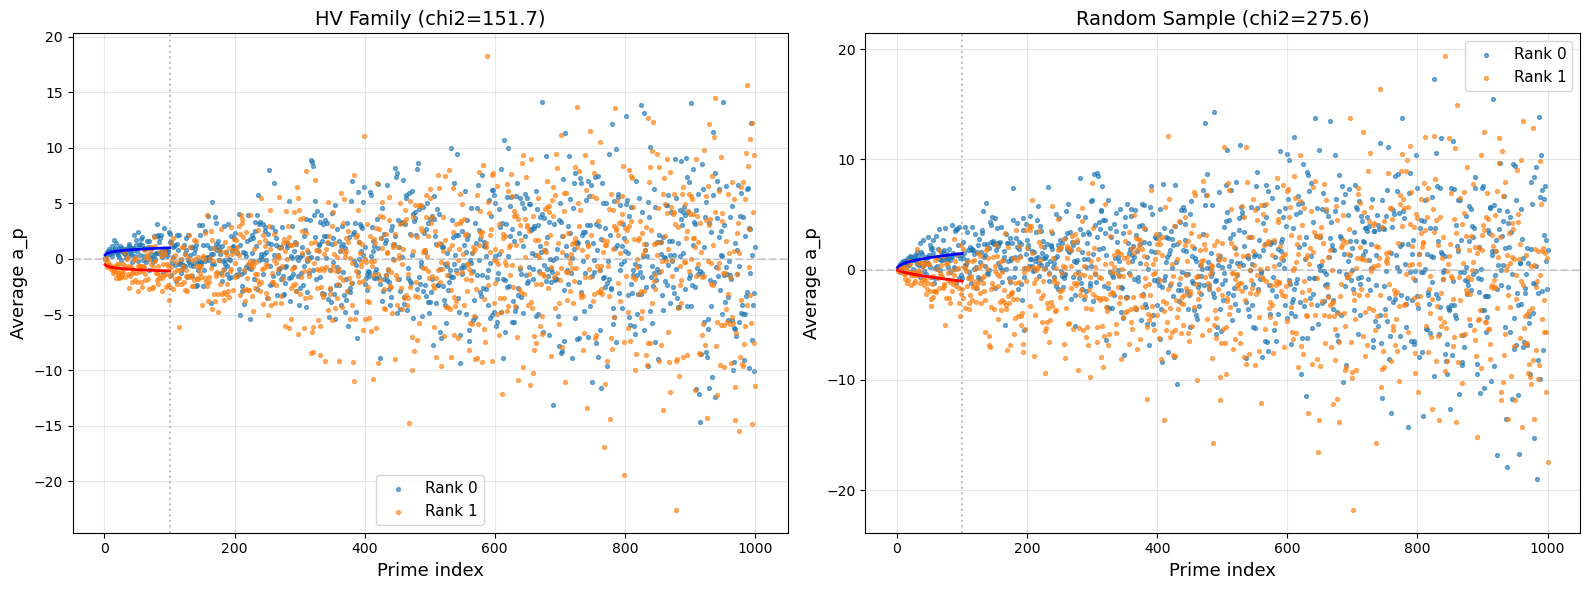


✓ SUCCESS - FINAL SUMMARY
Family: HV
Curves: 194 rank 0, 162 rank 1
Family chi² = 151.71
Random chi² = 275.58

🎯 HV is 1.82x cleaner!


In [4]:
output = run_family_analysis(
    family_name="HV",
    a_coeffs={   4: -243,
    3: 324,
    2: -810,
    1: 324,
    0: -27},
    b_coeffs={6: -1458,
    5: 2916,
    4: 7290,
    3: -9720,
    2: 5346,
    1: -972,
    0: 54},
    phi_range_m=(-20, 21),
    phi_range_n=(-20, 21),
    n_fit=100,
    seed=42
)

Family: BICUBIC
a(φ) = -648*phi - 27
b(φ) = 11664*phi^2 + 1944*phi + 54

STEP 1: ANALYZING BICUBIC FAMILY

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [00:43<00:00, 11.62it/s]



RESULTS FOR BICUBIC
Total phis tried: 511
Hits (N < 100,000): 329
Misses (N >= 100,000 or singular): 182
Efficiency: 64.4%

Distinct isogeny classes: 329
Redundant hits (same iso class): 0

Multiplicity distribution:
  1x: 329 isogeny classes

Top 10 highest multiplicity isogeny classes:
  14a: 1 phis → [1]
  110b: 1 phis → [2]
  246f: 1 phis → [3]
  218a: 1 phis → [4]
  170d: 1 phis → [5]
  978h: 1 phis → [6]
  1330e: 1 phis → [7]
  434b: 1 phis → [8]
  366f: 1 phis → [9]
  2710f: 1 phis → [10]

Rank 0: 177 curves
Rank 1: 146 curves

Saved to Fast_Murmuration_Search/BICUBIC_avg_aps.sobj


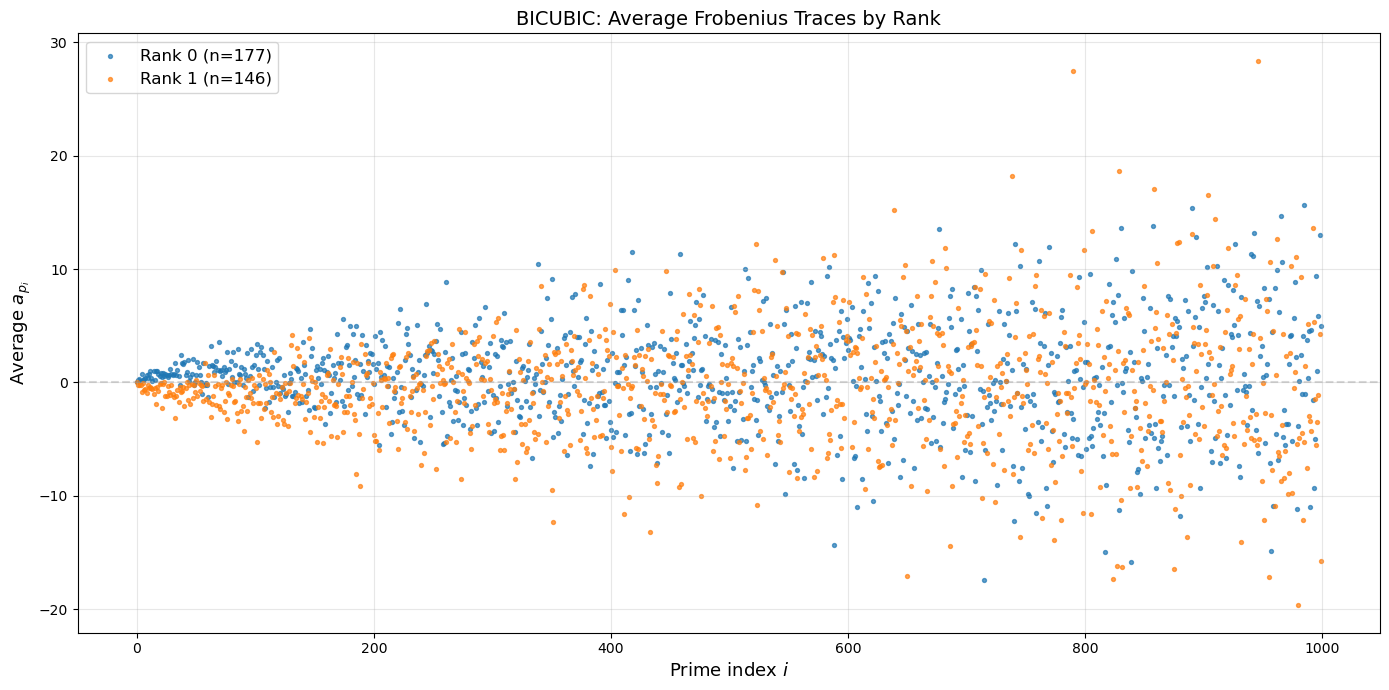

Plot saved to Fast_Murmuration_Search/BICUBIC_avg_aps.png

STEP 2: COMPARING TO RANDOM SAMPLES
Loading data from Fast_Murmuration_Search/BICUBIC_avg_aps.sobj...

BICUBIC family: 177 rank 0, 146 rank 1 curves

Fitting first 100 primes for BICUBIC...

Rank 0 fit: 0.2888 * x^0.2974
  chi2 = 75.30

Rank 1 fit: -0.2334 * x^0.3648
  chi2 = 92.62

Total chi2 for BICUBIC = 167.92

Drawing random sample from database...

Fitting random sample (first 100 primes)...
Random sample rank 0 fit: 0.1753 * x^0.4748, chi2=129.25
Random sample rank 1 fit: -0.0750 * x^0.6017, chi2=163.29
Random total chi2 = 292.54

--- COMPARISON ---
BICUBIC total chi2:     167.92
Random total chi2: 292.54
BICUBIC is 1.74x cleaner than random

Saved power law fit plot to Fast_Murmuration_Search/BICUBIC_power_law_fit.png


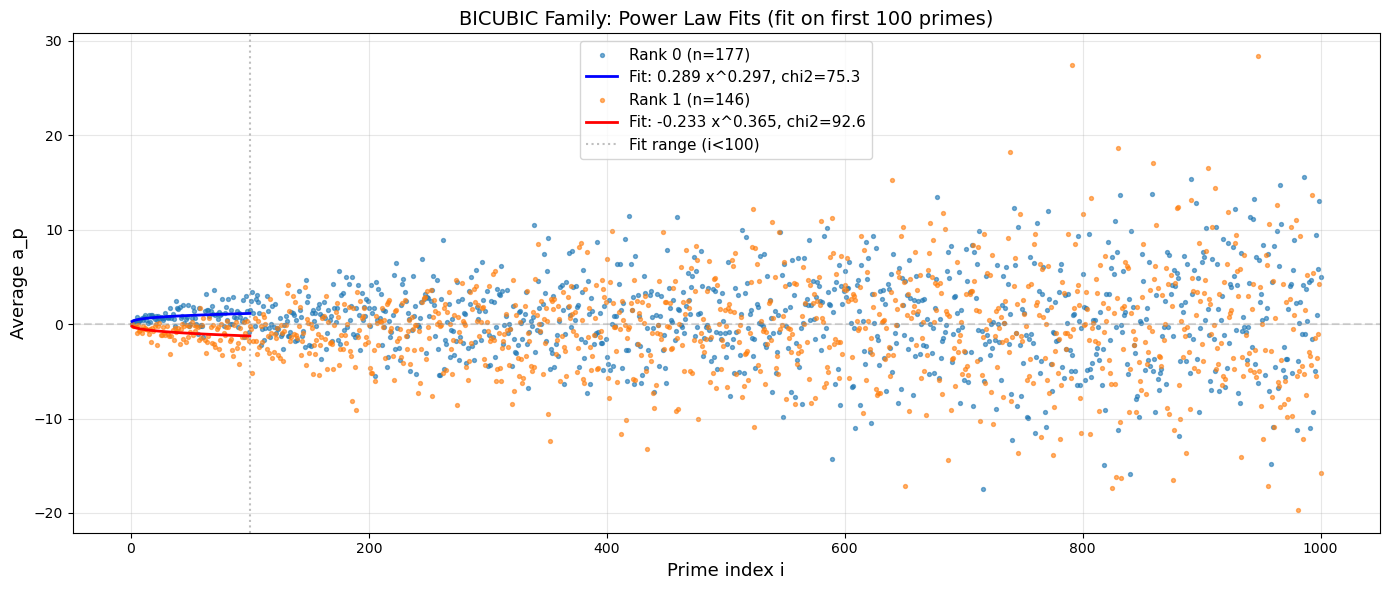

Saved comparison plot to Fast_Murmuration_Search/BICUBIC_vs_random.png


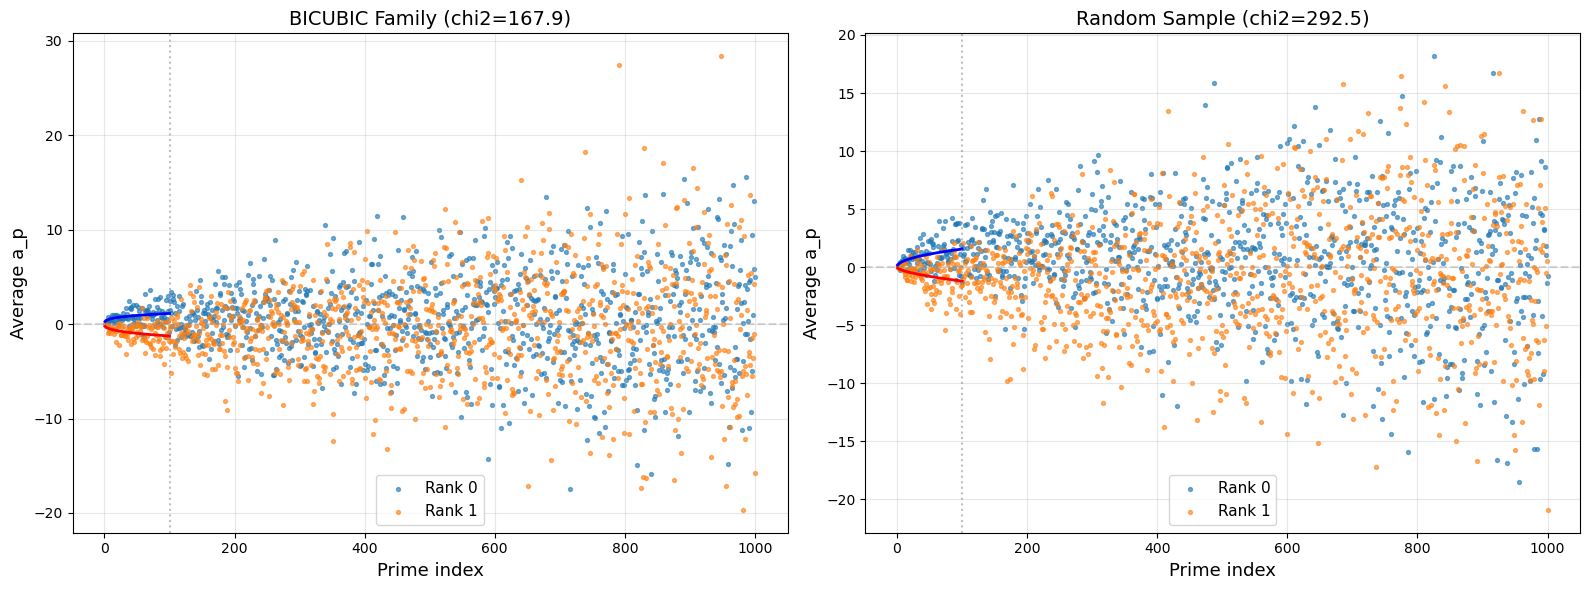


✓ SUCCESS - FINAL SUMMARY
Family: BICUBIC
Curves: 177 rank 0, 146 rank 1
Family chi² = 167.92
Random chi² = 292.54

🎯 BICUBIC is 1.74x cleaner!


In [2]:
# ============================================================================
# USE IT
# ============================================================================

output = run_family_analysis(
    family_name="BICUBIC",
    a_coeffs={1: -27*24, 0: -27},
    b_coeffs={2: 54*216, 1: 54*36, 0: 54},
    phi_range_m=(-20, 21),
    phi_range_n=(-20, 21),
    n_fit=100,
    seed=42
)

Family: SPLIT QUINTIC
a(φ) = -27*phi^4 + 324*phi^3 - 378*phi^2 - 324*phi - 27
b(φ) = 54*phi^6 - 972*phi^5 + 4050*phi^4 + 4050*phi^2 + 972*phi + 54

STEP 1: ANALYZING SPLIT QUINTIC FAMILY

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [00:35<00:00, 14.59it/s]



RESULTS FOR SPLIT QUINTIC
Total phis tried: 511
Hits (N < 100,000): 364
Misses (N >= 100,000 or singular): 147
Efficiency: 71.2%

Distinct isogeny classes: 178
Redundant hits (same iso class): 186

Multiplicity distribution:
  2x: 174 isogeny classes
  4x: 4 isogeny classes

Top 10 highest multiplicity isogeny classes:
  11a: 4 phis → [1, 11, -1/11, -1]
  50b: 4 phis → [8, -1/8, 1/2, -2]
  66c: 4 phis → [12, -2/9, -1/12, 9/2]
  150a: 4 phis → [18, -3/4, 4/3, -1/18]
  38b: 2 phis → [2, -1/2]
  75c: 2 phis → [3, -1/3]
  58b: 2 phis → [4, -1/4]
  155a: 2 phis → [5, -1/5]
  186b: 2 phis → [6, -1/6]
  203a: 2 phis → [7, -1/7]

Rank 0: 92 curves
Rank 1: 83 curves

Saved to Fast_Murmuration_Search/SPLIT_QUINTIC_avg_aps.sobj


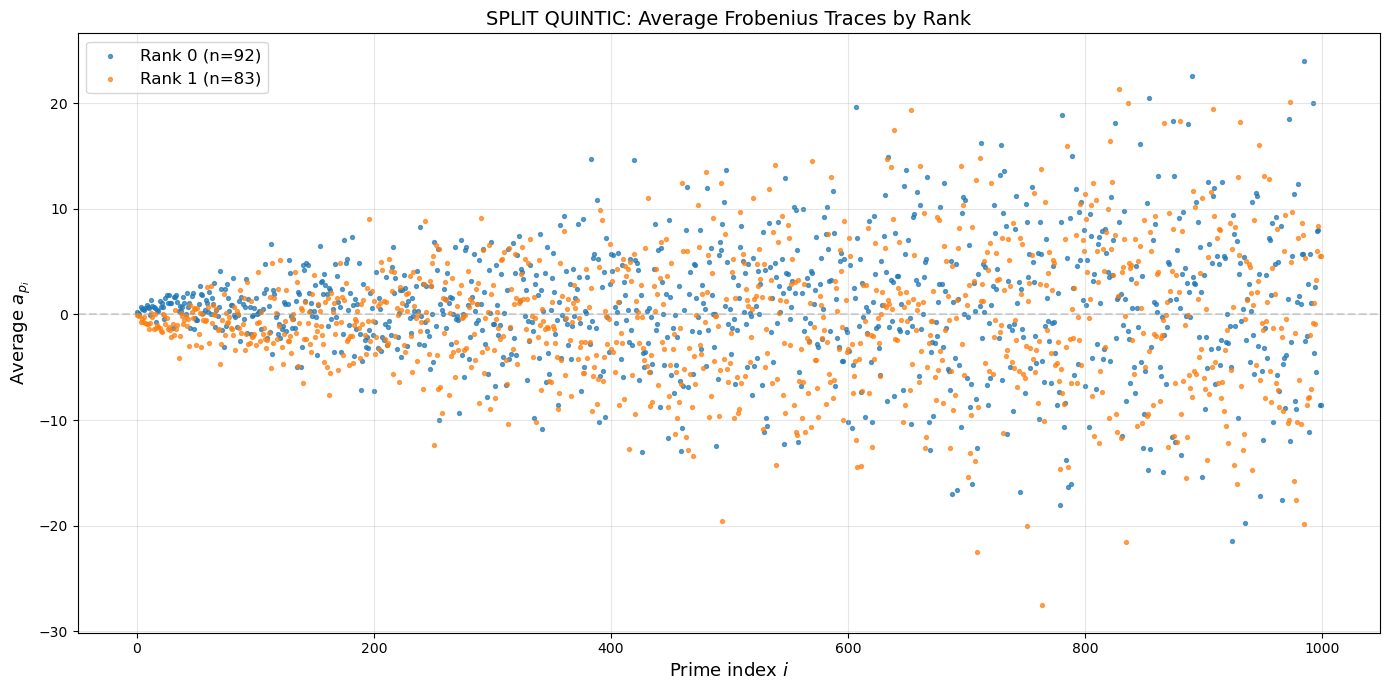

Plot saved to Fast_Murmuration_Search/SPLIT_QUINTIC_avg_aps.png

STEP 2: COMPARING TO RANDOM SAMPLES
Loading data from Fast_Murmuration_Search/SPLIT_QUINTIC_avg_aps.sobj...

SPLIT QUINTIC family: 92 rank 0, 83 rank 1 curves

Fitting first 100 primes for SPLIT QUINTIC...

Rank 0 fit: 0.6146 * x^0.0271
  chi2 = 151.17

Rank 1 fit: -0.5826 * x^0.0704
  chi2 = 188.81

Total chi2 for SPLIT QUINTIC = 339.98

Drawing random sample from database...

Fitting random sample (first 100 primes)...
Random sample rank 0 fit: 0.1446 * x^0.4935, chi2=176.71
Random sample rank 1 fit: -0.0497 * x^0.7343, chi2=342.92
Random total chi2 = 519.64

--- COMPARISON ---
SPLIT QUINTIC total chi2:     339.98
Random total chi2: 519.64
SPLIT QUINTIC is 1.53x cleaner than random

Saved power law fit plot to Fast_Murmuration_Search/SPLIT_QUINTIC_power_law_fit.png


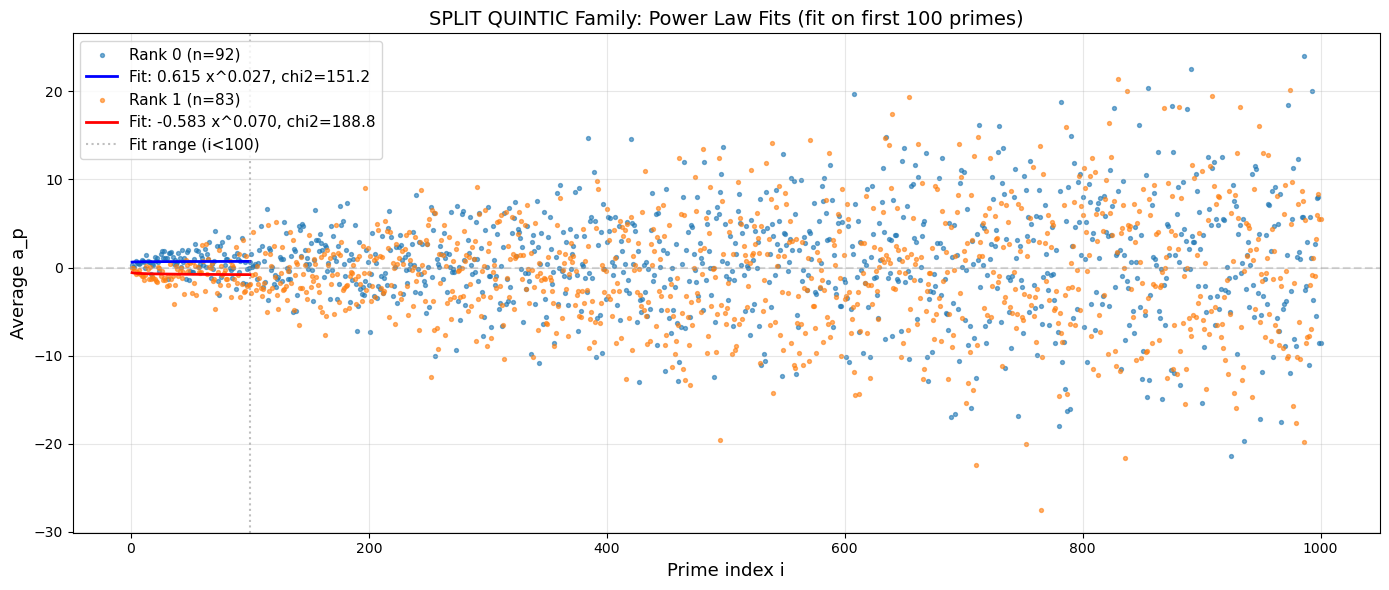

Saved comparison plot to Fast_Murmuration_Search/SPLIT_QUINTIC_vs_random.png


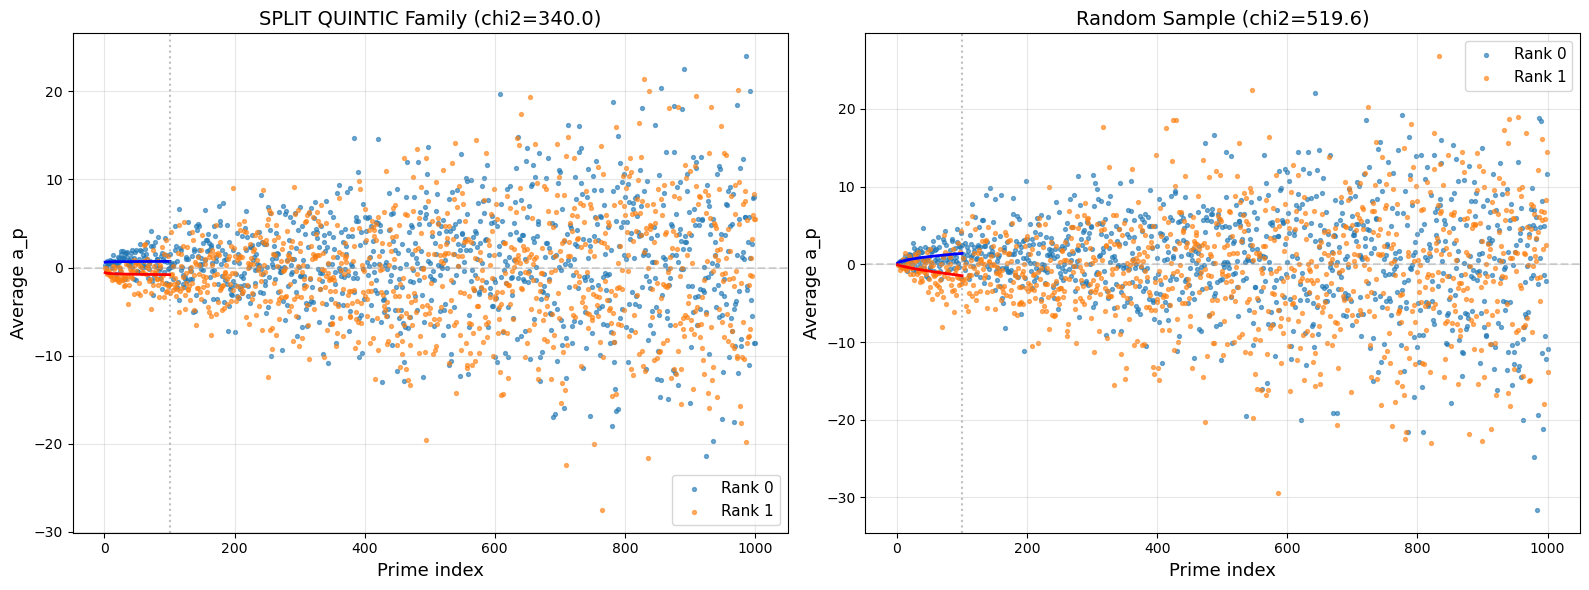


✓ SUCCESS - FINAL SUMMARY
Family: SPLIT QUINTIC
Curves: 92 rank 0, 83 rank 1
Family chi² = 339.98
Random chi² = 519.64

🎯 SPLIT QUINTIC is 1.53x cleaner!


In [5]:
output = run_family_analysis(
    family_name="SPLIT QUINTIC",
    a_coeffs={4: -27, 3: 27*12, 2: -27*14, 1: -27*12, 0: -27},
    b_coeffs={6: 54, 5: -54*18, 4: 54*75, 2: 54*75, 1: 54*18, 0: 54},
    phi_range_m=(-20, 21),
    phi_range_n=(-20, 21),
    n_fit=100,
    seed=42
)

Family: Z_2 TORSION
a(φ) = 81*phi - 27
b(φ) = -243*phi + 54

STEP 1: ANALYZING Z_2 TORSION FAMILY

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [00:44<00:00, 11.44it/s]



RESULTS FOR Z_2 TORSION
Total phis tried: 511
Hits (N < 100,000): 314
Misses (N >= 100,000 or singular): 197
Efficiency: 61.4%

Distinct isogeny classes: 312
Redundant hits (same iso class): 2

Multiplicity distribution:
  1x: 310 isogeny classes
  2x: 2 isogeny classes

Top 10 highest multiplicity isogeny classes:
  192b: 2 phis → [1/16, 9/4]
  96a: 2 phis → [3/16, -2]
  48a: 1 phis → [1]
  224a: 1 phis → [2]
  132a: 1 phis → [3]
  120b: 1 phis → [4]
  1520d: 1 phis → [5]
  2208e: 1 phis → [6]
  84a: 1 phis → [7]
  248b: 1 phis → [8]

Rank 0: 166 curves
Rank 1: 143 curves

Saved to Fast_Murmuration_Search/Z_2_TORSION_avg_aps.sobj


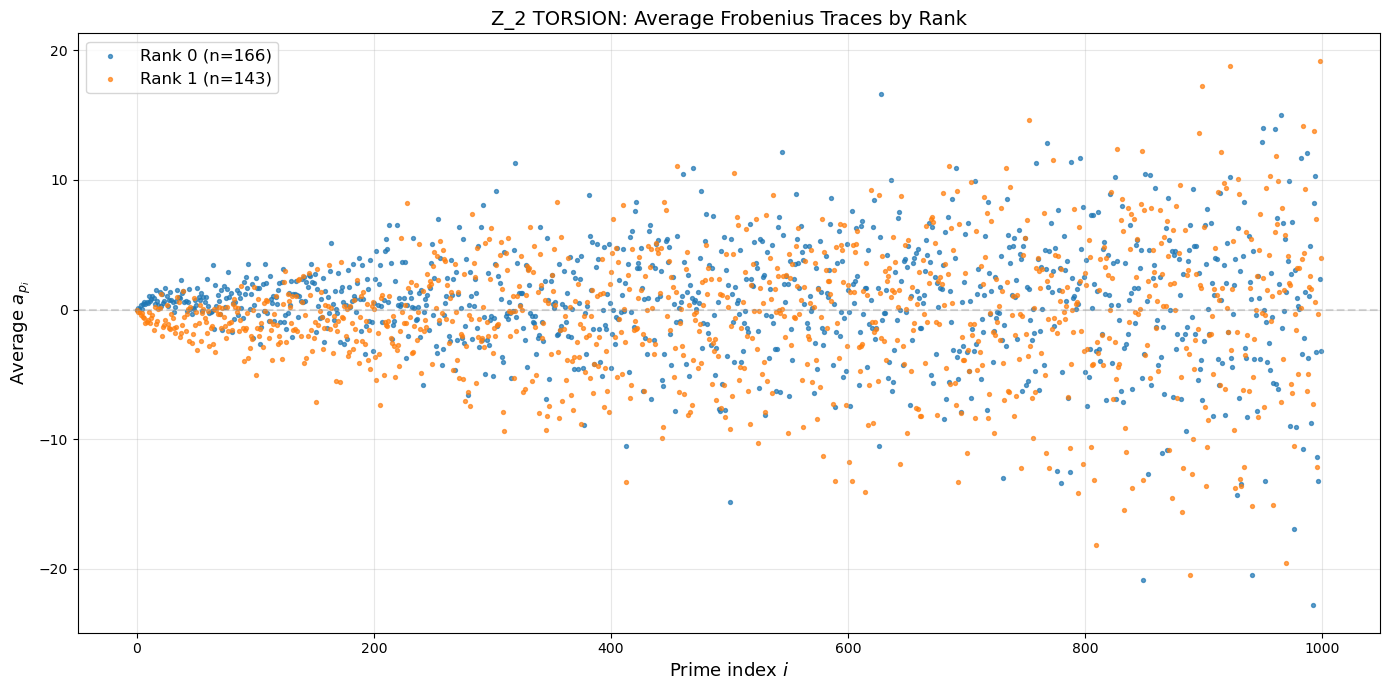

Plot saved to Fast_Murmuration_Search/Z_2_TORSION_avg_aps.png

STEP 2: COMPARING TO RANDOM SAMPLES
Loading data from Fast_Murmuration_Search/Z_2_TORSION_avg_aps.sobj...

Z_2 TORSION family: 166 rank 0, 143 rank 1 curves

Fitting first 100 primes for Z_2 TORSION...

Rank 0 fit: 0.4155 * x^0.1487
  chi2 = 87.44

Rank 1 fit: -0.3305 * x^0.2541
  chi2 = 122.84

Total chi2 for Z_2 TORSION = 210.28

Drawing random sample from database...

Fitting random sample (first 100 primes)...
Random sample rank 0 fit: 0.1282 * x^0.5586, chi2=134.45
Random sample rank 1 fit: -0.0821 * x^0.5800, chi2=154.16
Random total chi2 = 288.61

--- COMPARISON ---
Z_2 TORSION total chi2:     210.28
Random total chi2: 288.61
Z_2 TORSION is 1.37x cleaner than random

Saved power law fit plot to Fast_Murmuration_Search/Z_2_TORSION_power_law_fit.png


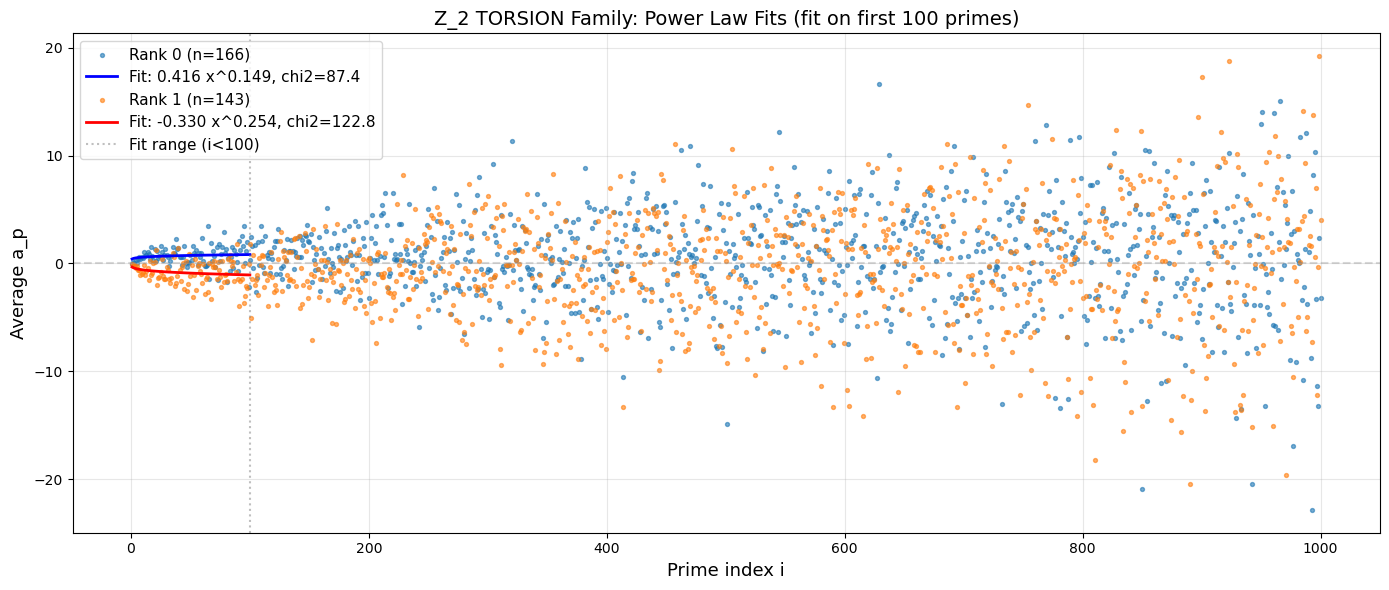

Saved comparison plot to Fast_Murmuration_Search/Z_2_TORSION_vs_random.png


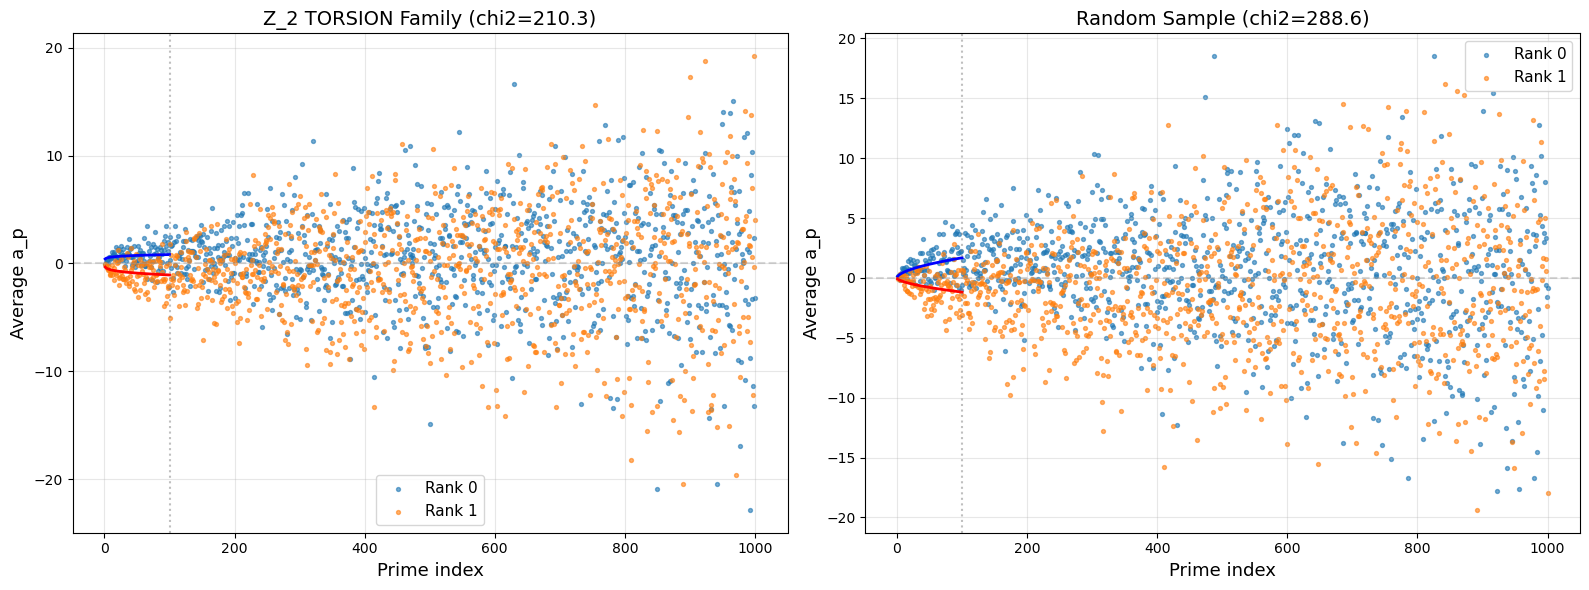


✓ SUCCESS - FINAL SUMMARY
Family: Z_2 TORSION
Curves: 166 rank 0, 143 rank 1
Family chi² = 210.28
Random chi² = 288.61

🎯 Z_2 TORSION is 1.37x cleaner!
Family: Z_3 TORSION
a(φ) = 72*phi - 3
b(φ) = 432*phi^2 - 72*phi + 2

STEP 1: ANALYZING Z_3 TORSION FAMILY

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [00:37<00:00, 13.67it/s]



RESULTS FOR Z_3 TORSION
Total phis tried: 511
Hits (N < 100,000): 124
Misses (N >= 100,000 or singular): 387
Efficiency: 24.3%

Distinct isogeny classes: 124
Redundant hits (same iso class): 0

Multiplicity distribution:
  1x: 124 isogeny classes

Top 10 highest multiplicity isogeny classes:
  1872s: 1 phis → [1]
  7632q: 1 phis → [2]
  720j: 1 phis → [3]
  15408bc: 1 phis → [4]
  48240bk: 1 phis → [5]
  23184bk: 1 phis → [6]
  47376bg: 1 phis → [7]
  30960bv: 1 phis → [8]
  1584l: 1 phis → [9]
  58608br: 1 phis → [11]

Rank 0: 55 curves
Rank 1: 63 curves

Saved to Fast_Murmuration_Search/Z_3_TORSION_avg_aps.sobj


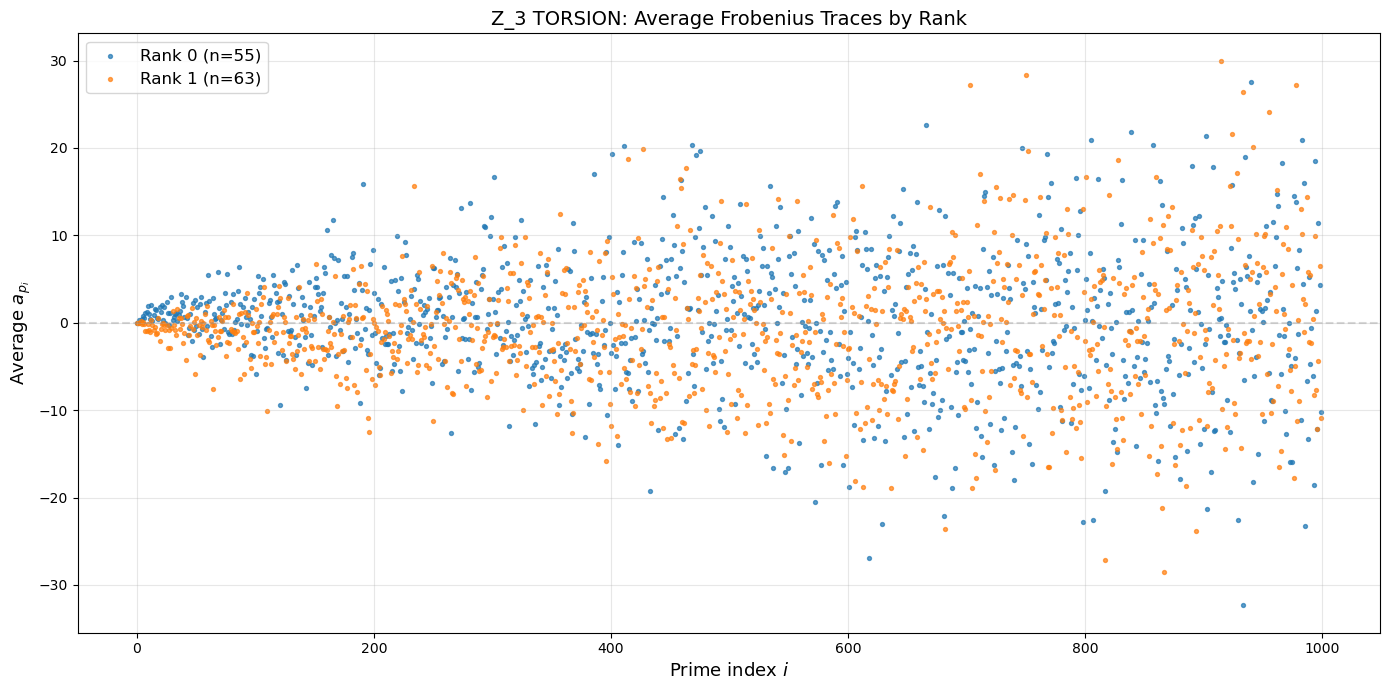

Plot saved to Fast_Murmuration_Search/Z_3_TORSION_avg_aps.png

STEP 2: COMPARING TO RANDOM SAMPLES
Loading data from Fast_Murmuration_Search/Z_3_TORSION_avg_aps.sobj...

Z_3 TORSION family: 55 rank 0, 63 rank 1 curves

Fitting first 100 primes for Z_3 TORSION...

Rank 0 fit: 0.7667 * x^0.0516
  chi2 = 344.93

Rank 1 fit: -0.1107 * x^0.5282
  chi2 = 319.96

Total chi2 for Z_3 TORSION = 664.88

Drawing random sample from database...

Fitting random sample (first 100 primes)...
Random sample rank 0 fit: 0.4953 * x^0.1948, chi2=305.61
Random sample rank 1 fit: -0.1252 * x^0.3792, chi2=360.61
Random total chi2 = 666.22

--- COMPARISON ---
Z_3 TORSION total chi2:     664.88
Random total chi2: 666.22
Z_3 TORSION is 1.00x cleaner than random

Saved power law fit plot to Fast_Murmuration_Search/Z_3_TORSION_power_law_fit.png


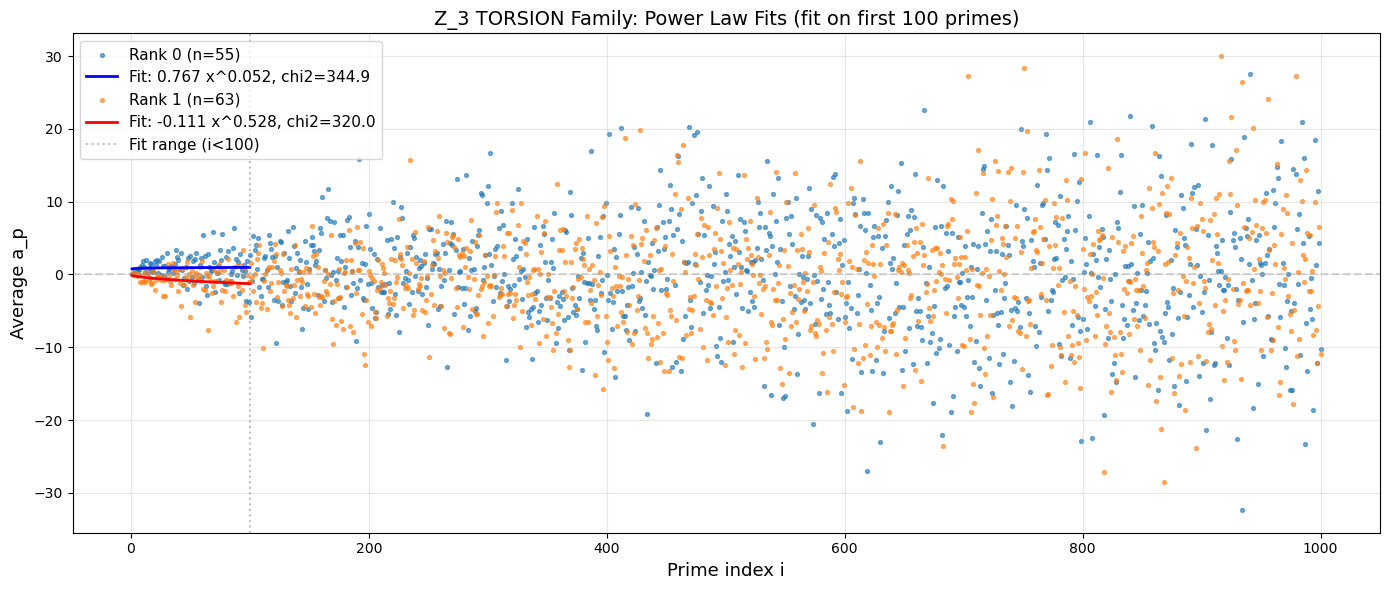

Saved comparison plot to Fast_Murmuration_Search/Z_3_TORSION_vs_random.png


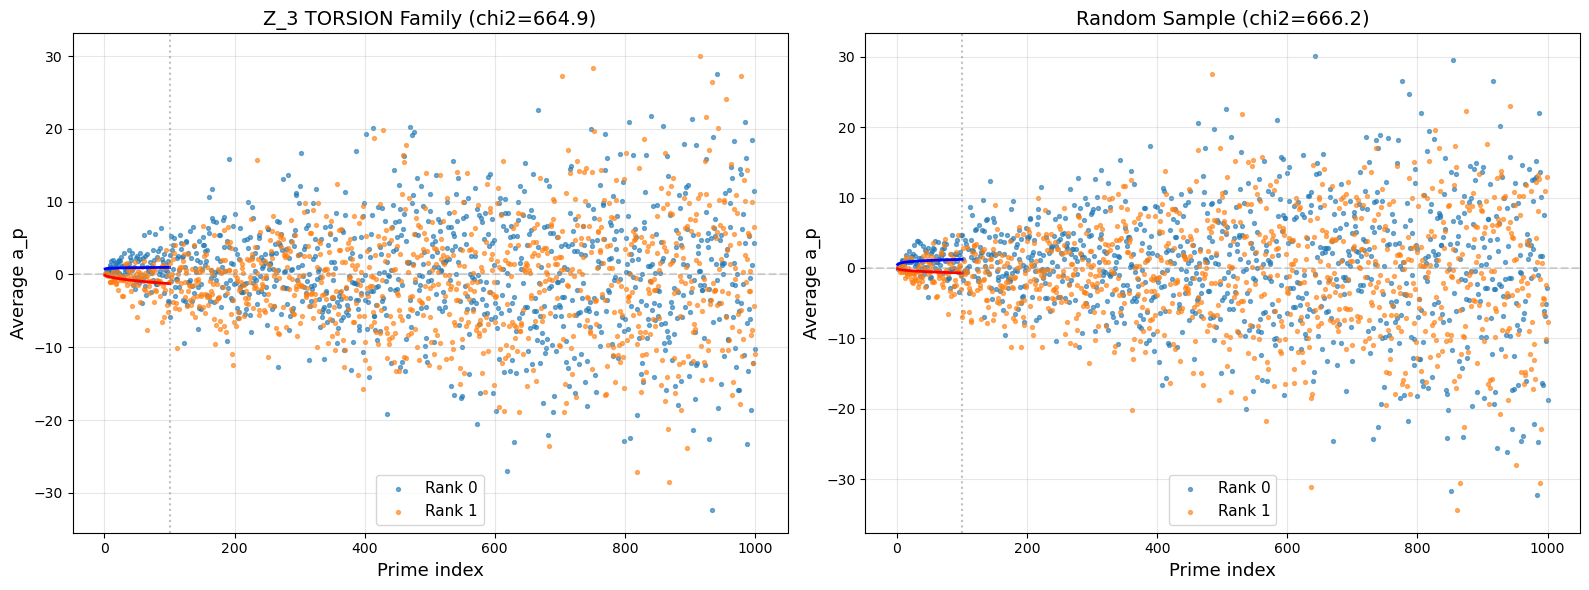


✓ SUCCESS - FINAL SUMMARY
Family: Z_3 TORSION
Curves: 55 rank 0, 63 rank 1
Family chi² = 664.88
Random chi² = 666.22

🎯 Z_3 TORSION is 1.00x cleaner!
Family: Z_4 TORSION
a(φ) = -48*phi^2 + 48*phi - 3
b(φ) = 128*phi^3 + 240*phi^2 - 48*phi + 2

STEP 1: ANALYZING Z_4 TORSION FAMILY

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


 29%|███████████████████████▎                                                         | 147/511 [00:12<00:34, 10.65it/s]

In [ ]:
# Z_2: u^2 = 9 (as in your original)
# a = phi - 1/3,  b = 2/27 - phi/3
output_Z2 = run_family_analysis(
    family_name="Z_2 TORSION",
    a_coeffs={1: 81, 0: -81*1/3},
    b_coeffs={1: -27*9, 0: 27*2},
    phi_range_m=(-20, 21),
    phi_range_n=(-20, 21),
    n_fit=100,
    seed=42
)

# Z_3: u^2 = 12
# a = phi/2 - 1/48,  b = phi^2/4 - phi/24 + 1/864
output_Z3 = run_family_analysis(
    family_name="Z_3 TORSION",
    a_coeffs={1: 72, 0: -3},
    b_coeffs={2: 432, 1: -72, 0: 2},
    phi_range_m=(-20, 21),
    phi_range_n=(-20, 21),
    n_fit=100,
    seed=42
)

Family: Z_4 TORSION
a(φ) = -48*phi^2 + 48*phi - 3
b(φ) = 128*phi^3 + 240*phi^2 - 48*phi + 2

STEP 1: ANALYZING Z_4 TORSION FAMILY

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [00:59<00:00,  8.58it/s]



RESULTS FOR Z_4 TORSION
Total phis tried: 511
Hits (N < 100,000): 201
Misses (N >= 100,000 or singular): 310
Efficiency: 39.3%

Distinct isogeny classes: 194
Redundant hits (same iso class): 7

Multiplicity distribution:
  1x: 189 isogeny classes
  2x: 3 isogeny classes
  3x: 2 isogeny classes

Top 10 highest multiplicity isogeny classes:
  720h: 3 phis → [1, -1/9, -5]
  144b: 3 phis → [1/4, -1/2, 1/18]
  1008k: 2 phis → [1/9, -3]
  288d: 2 phis → [1/8, -1/16]
  72a: 2 phis → [-3/16, 9/16]
  4464x: 1 phis → [2]
  6768p: 1 phis → [3]
  1008l: 1 phis → [4]
  56880bk: 1 phis → [5]
  13680bh: 1 phis → [6]

Rank 0: 99 curves
Rank 1: 88 curves

Saved to Fast_Murmuration_Search/Z_4_TORSION_avg_aps.sobj


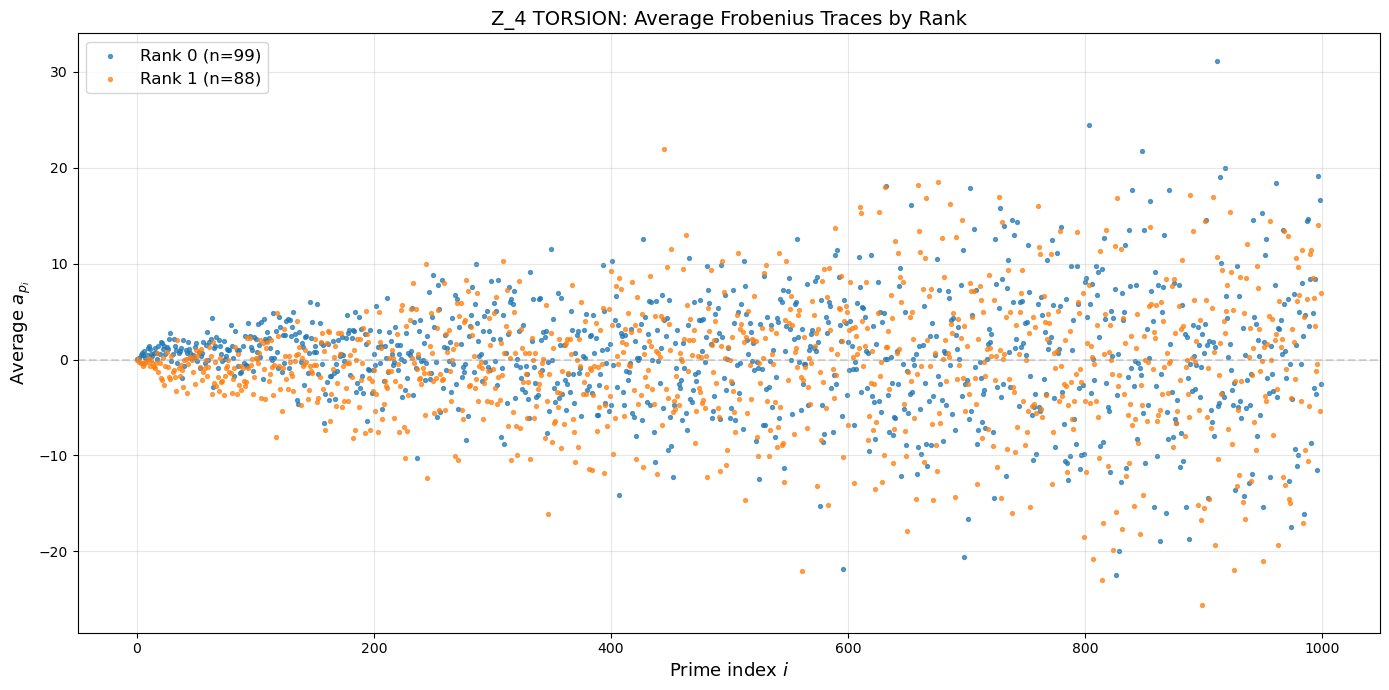

Plot saved to Fast_Murmuration_Search/Z_4_TORSION_avg_aps.png

STEP 2: COMPARING TO RANDOM SAMPLES
Loading data from Fast_Murmuration_Search/Z_4_TORSION_avg_aps.sobj...

Z_4 TORSION family: 99 rank 0, 88 rank 1 curves

Fitting first 100 primes for Z_4 TORSION...

Rank 0 fit: 0.5804 * x^0.1054
  chi2 = 140.04

Rank 1 fit: -0.1691 * x^0.4419
  chi2 = 182.34

Total chi2 for Z_4 TORSION = 322.38

Drawing random sample from database...

Fitting random sample (first 100 primes)...
Random sample rank 0 fit: 0.1086 * x^0.5784, chi2=168.27
Random sample rank 1 fit: -0.0323 * x^0.8292, chi2=322.47
Random total chi2 = 490.74

--- COMPARISON ---
Z_4 TORSION total chi2:     322.38
Random total chi2: 490.74
Z_4 TORSION is 1.52x cleaner than random

Saved power law fit plot to Fast_Murmuration_Search/Z_4_TORSION_power_law_fit.png


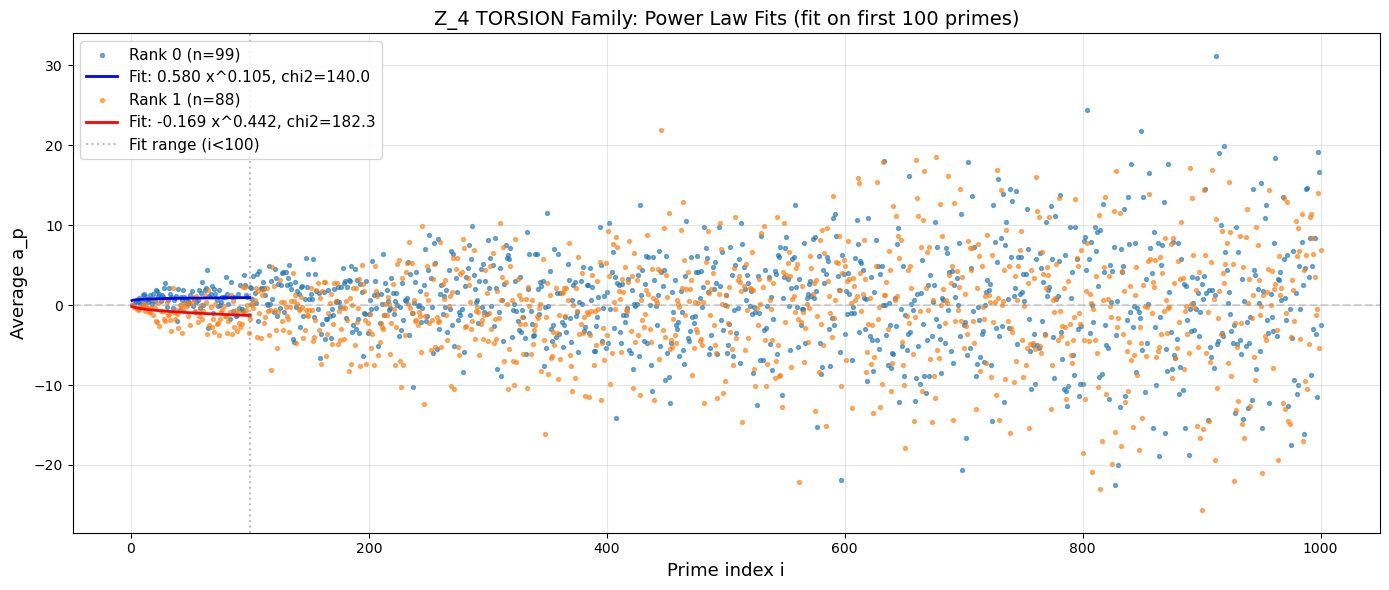

Saved comparison plot to Fast_Murmuration_Search/Z_4_TORSION_vs_random.png


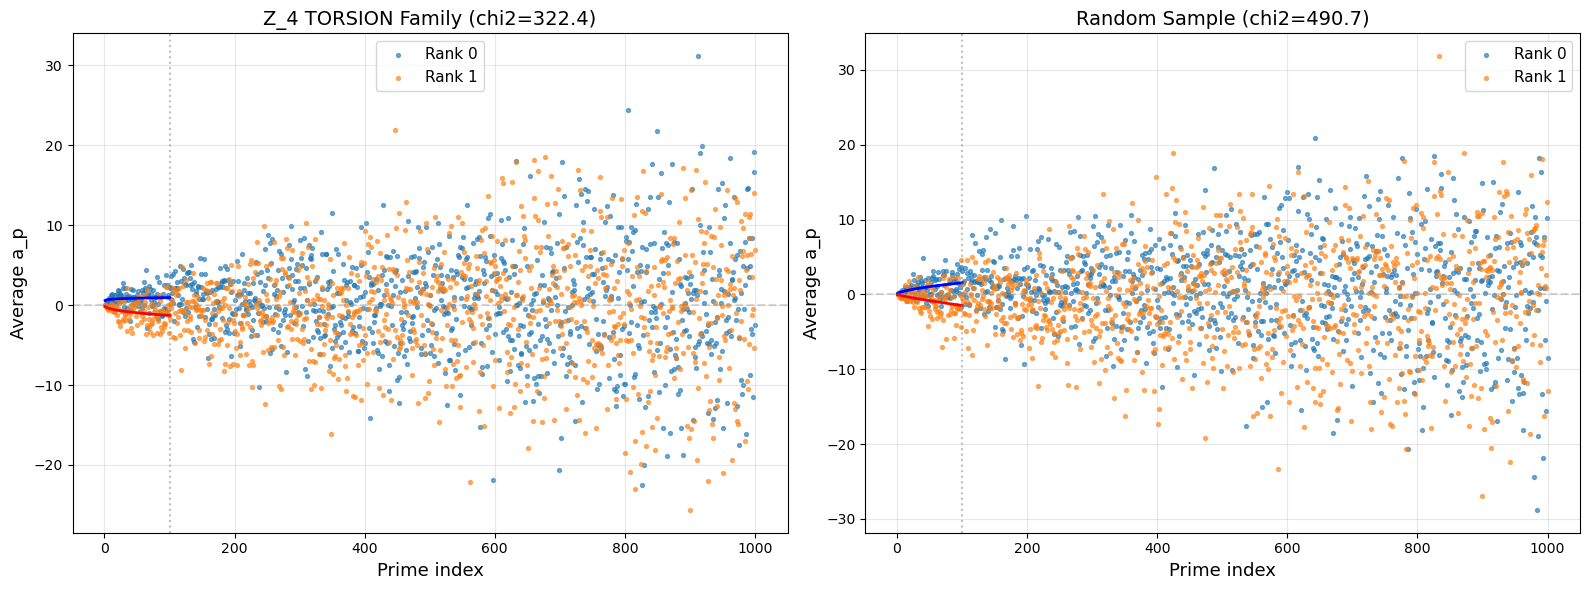


✓ SUCCESS - FINAL SUMMARY
Family: Z_4 TORSION
Curves: 99 rank 0, 88 rank 1
Family chi² = 322.38
Random chi² = 490.74

🎯 Z_4 TORSION is 1.52x cleaner!


In [3]:
# Z_4: u^2 = 12
# a = -phi^2/3 + phi/3 - 1/48
# b = 2*phi^3/27 + 5*phi^2/36 - phi/36 + 1/864
output_Z4 = run_family_analysis(
    family_name="Z_4 TORSION",
    a_coeffs={2: -48, 1: 48, 0: -3},
    b_coeffs={3: 128, 2: 240, 1: -48, 0: 2},
    phi_range_m=(-20, 21),
    phi_range_n=(-20, 21),
    n_fit=100,
    seed=42
)

Family: Z_5 TORSION
a(φ) = -48*phi^4 + 24*phi^3 + 48*phi^2 - 24*phi - 3
b(φ) = 304*phi^6 - 768*phi^5 + 720*phi^4 - 280*phi^3 + 24*phi + 2

STEP 1: ANALYZING Z_5 TORSION FAMILY

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [01:26<00:00,  5.91it/s]



RESULTS FOR Z_5 TORSION
Total phis tried: 511
Hits (N < 100,000): 93
Misses (N >= 100,000 or singular): 418
Efficiency: 18.2%

Distinct isogeny classes: 44
Redundant hits (same iso class): 49

Multiplicity distribution:
  1x: 2 isogeny classes
  2x: 38 isogeny classes
  3x: 1 isogeny classes
  4x: 3 isogeny classes

Top 10 highest multiplicity isogeny classes:
  3600bi: 4 phis → [2, 8/9, -1/7, 1/3]
  3600bm: 4 phis → [-1/17, 4/7, 18/19, -3]
  1584s: 4 phis → [-2/7, 12/13, -1/11, 9/11]
  1584p: 3 phis → [11/12, 1/2, -1/10]
  10224q: 2 phis → [3, 2/5]
  20016bc: 2 phis → [4, 3/7]
  39600fe: 2 phis → [-2/9, 11/13]
  7920bd: 2 phis → [-1/9, 10/11]
  21744v: 2 phis → [1/9, 8/7]
  62064y: 2 phis → [1/17, 16/15]

Rank 0: 22 curves
Rank 1: 21 curves

Saved to Fast_Murmuration_Search/Z_5_TORSION_avg_aps.sobj


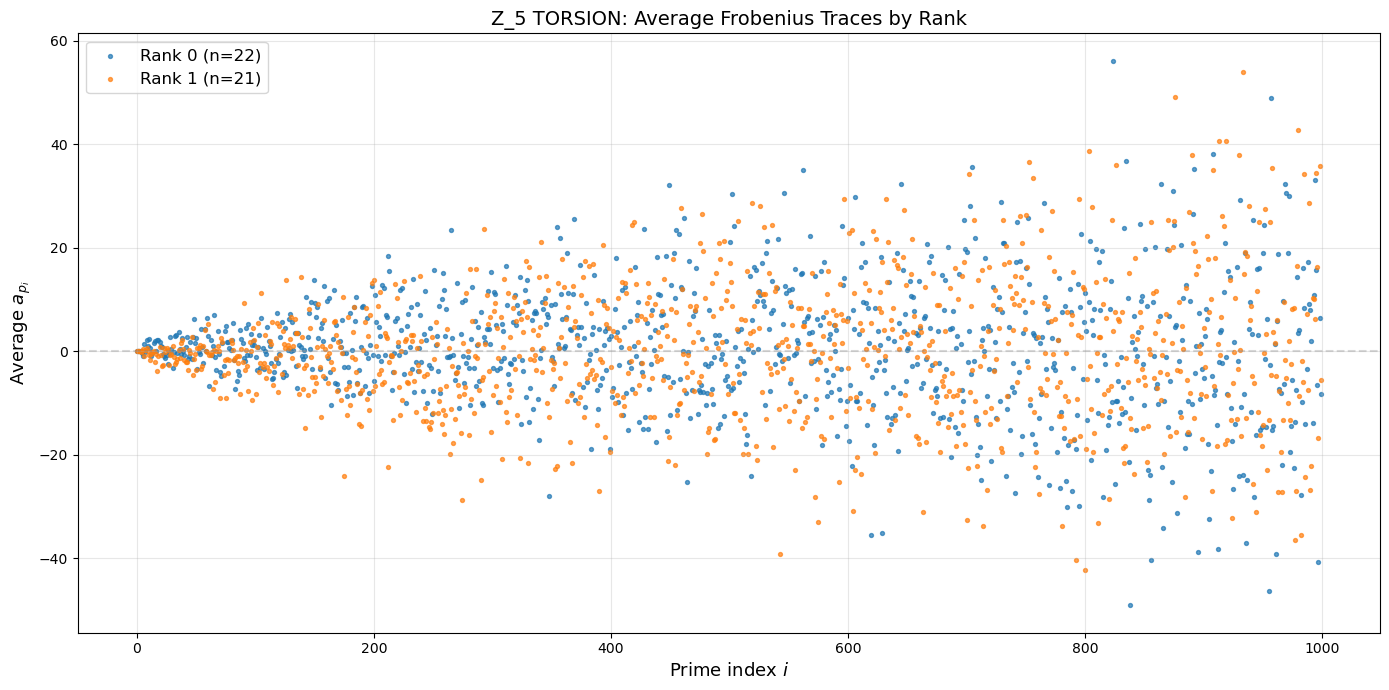

Plot saved to Fast_Murmuration_Search/Z_5_TORSION_avg_aps.png

STEP 2: COMPARING TO RANDOM SAMPLES
Loading data from Fast_Murmuration_Search/Z_5_TORSION_avg_aps.sobj...

Z_5 TORSION family: 22 rank 0, 21 rank 1 curves

Fitting first 100 primes for Z_5 TORSION...

Rank 0 fit: 0.4425 * x^0.0838
  chi2 = 726.49

Rank 1 fit: -0.1393 * x^0.4848
  chi2 = 809.20

Total chi2 for Z_5 TORSION = 1535.69

Drawing random sample from database...

Fitting random sample (first 100 primes)...
Random sample rank 0 fit: 0.0850 * x^0.7132, chi2=1147.61
Random sample rank 1 fit: -0.4395 * x^0.0012, chi2=1297.47
Random total chi2 = 2445.08

--- COMPARISON ---
Z_5 TORSION total chi2:     1535.69
Random total chi2: 2445.08
Z_5 TORSION is 1.59x cleaner than random

Saved power law fit plot to Fast_Murmuration_Search/Z_5_TORSION_power_law_fit.png


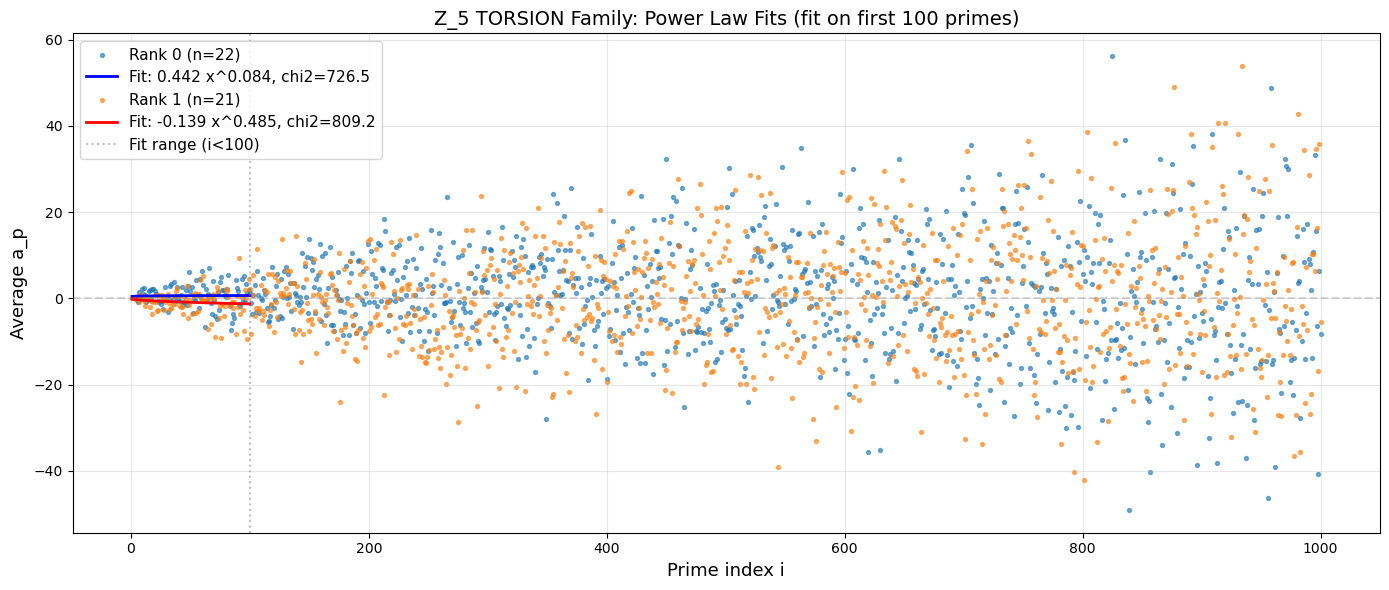

Saved comparison plot to Fast_Murmuration_Search/Z_5_TORSION_vs_random.png


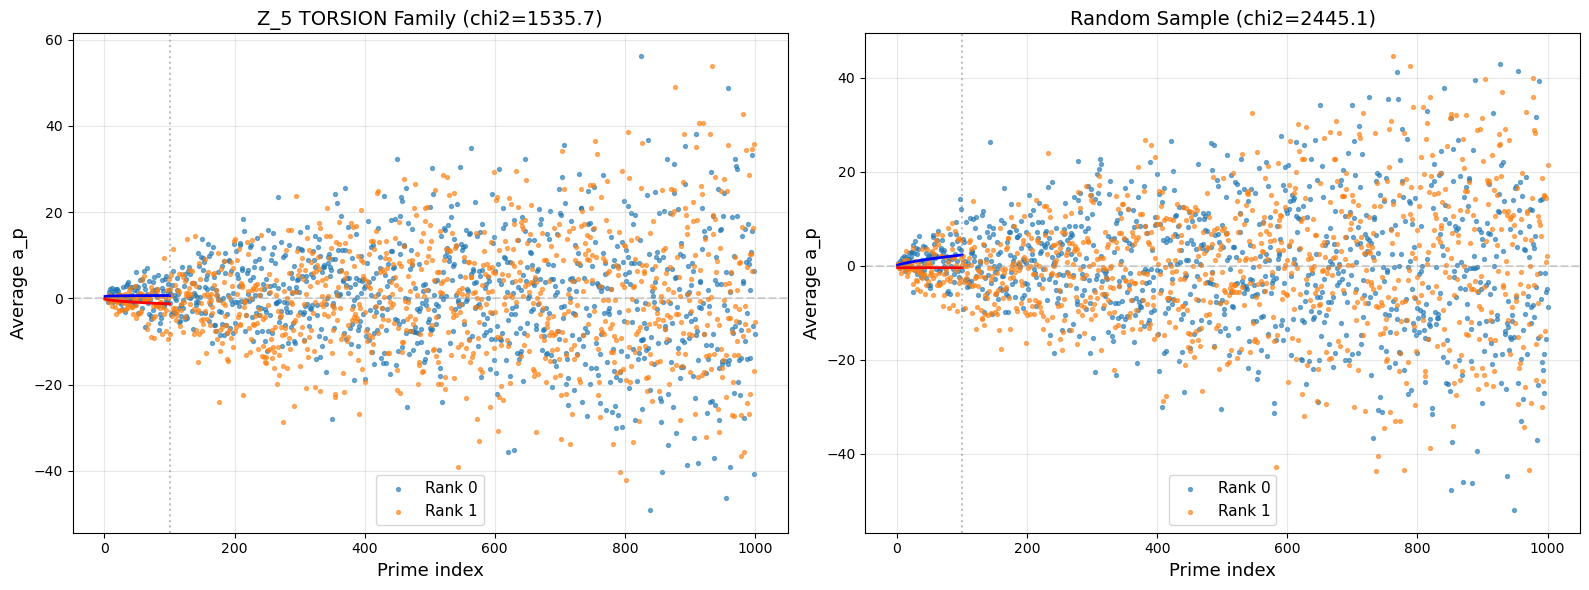


✓ SUCCESS - FINAL SUMMARY
Family: Z_5 TORSION
Curves: 22 rank 0, 21 rank 1
Family chi² = 1535.69
Random chi² = 2445.08

🎯 Z_5 TORSION is 1.59x cleaner!


In [4]:

# Z_5: u^2 = 12
# a = -phi^4/3 + phi^3/6 + phi^2/3 - phi/6 - 1/48
# b = (1/864)(1 - 2*phi + 2*phi^2)(1 + 14*phi + 26*phi^2 - 116*phi^3 + 76*phi^4)
#   = (1/864)(1 + 12*phi - 140*phi^3 + 360*phi^4 - 384*phi^5 + 152*phi^6)
output_Z5 = run_family_analysis(
    family_name="Z_5 TORSION",
    a_coeffs={4: -48, 3: 24, 2: 48, 1: -24, 0: -3},
    b_coeffs={6: 304, 5: -768, 4: 720, 3: -280, 1: 24, 0: 2},
    phi_range_m=(-20, 21),
    phi_range_n=(-20, 21),
    n_fit=100,
    seed=42
)

Family: Z_6 TORSION
a(φ) = -12*phi^4 - 36*phi^3 - 36*phi^2 + 36*phi
b(φ) = 11*phi^6 + 90*phi^5 + 117*phi^4 - 36*phi^3 - 27*phi^2 - 54*phi + 27

STEP 1: ANALYZING Z_6 TORSION FAMILY

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [02:10<00:00,  3.91it/s]



RESULTS FOR Z_6 TORSION
Total phis tried: 511
Hits (N < 100,000): 183
Misses (N >= 100,000 or singular): 328
Efficiency: 35.8%

Distinct isogeny classes: 116
Redundant hits (same iso class): 67

Multiplicity distribution:
  1x: 60 isogeny classes
  2x: 51 isogeny classes
  3x: 2 isogeny classes
  4x: 1 isogeny classes
  5x: 1 isogeny classes
  6x: 1 isogeny classes

Top 10 highest multiplicity isogeny classes:
  720j: 6 phis → [7, -13/5, -7/5, 1/5, 11/13]...
  5040bj: 5 phis → [-1/17, -11/5, 13/5, -13/11, 13/19]
  1008i: 4 phis → [5/9, -11/3, -1/3, 5/3]
  112c: 3 phis → [15, -15/17, 3/11]
  5040bc: 3 phis → [13/17, -19/11, -19]
  144a: 2 phis → [0, 3]
  5040bl: 2 phis → [2, -1/5]
  85680dz: 2 phis → [4, 1/11]
  1584l: 2 phis → [5, 1/7]
  1680l: 2 phis → [6, 3/17]

Rank 0: 63 curves
Rank 1: 51 curves

Saved to Fast_Murmuration_Search/Z_6_TORSION_avg_aps.sobj


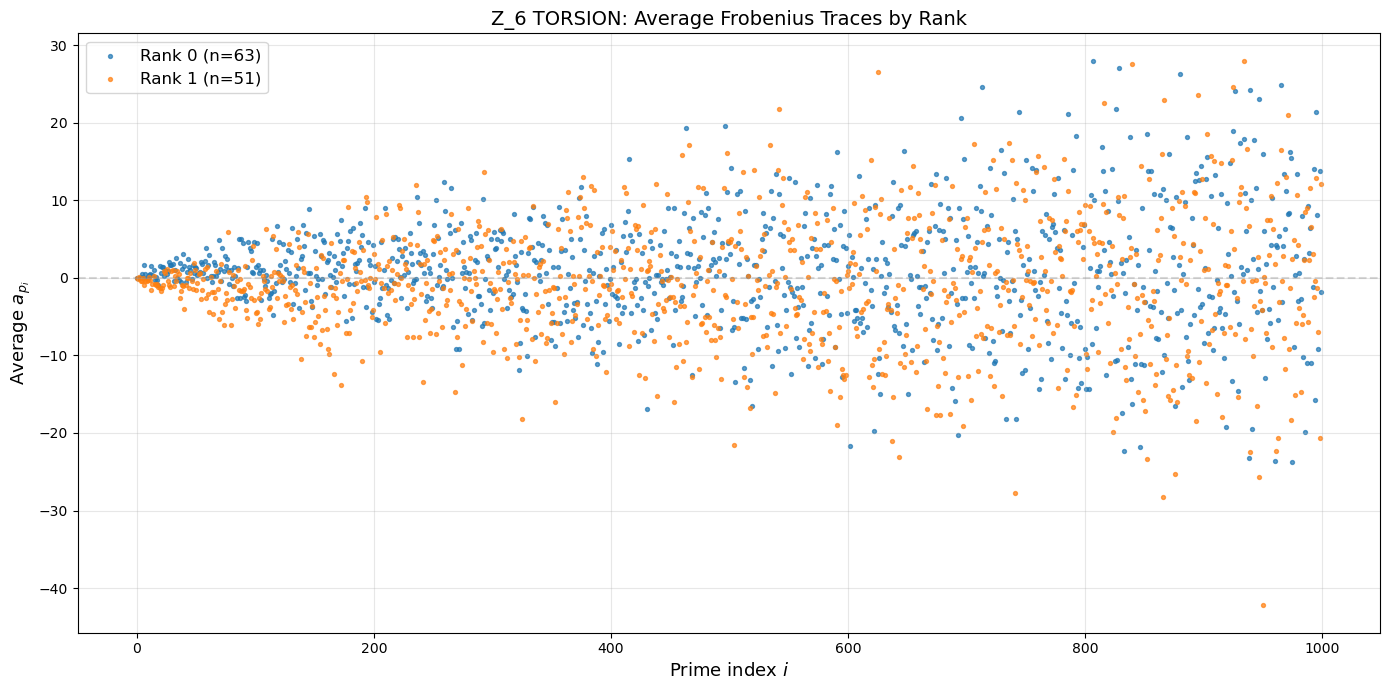

Plot saved to Fast_Murmuration_Search/Z_6_TORSION_avg_aps.png

STEP 2: COMPARING TO RANDOM SAMPLES
Loading data from Fast_Murmuration_Search/Z_6_TORSION_avg_aps.sobj...

Z_6 TORSION family: 63 rank 0, 51 rank 1 curves

Fitting first 100 primes for Z_6 TORSION...

Rank 0 fit: 0.1962 * x^0.4364
  chi2 = 242.70

Rank 1 fit: -0.0757 * x^0.6441
  chi2 = 358.57

Total chi2 for Z_6 TORSION = 601.27

Drawing random sample from database...

Fitting random sample (first 100 primes)...
Random sample rank 0 fit: 0.3753 * x^0.2777, chi2=270.00
Random sample rank 1 fit: -0.1883 * x^0.2370, chi2=550.10
Random total chi2 = 820.10

--- COMPARISON ---
Z_6 TORSION total chi2:     601.27
Random total chi2: 820.10
Z_6 TORSION is 1.36x cleaner than random

Saved power law fit plot to Fast_Murmuration_Search/Z_6_TORSION_power_law_fit.png


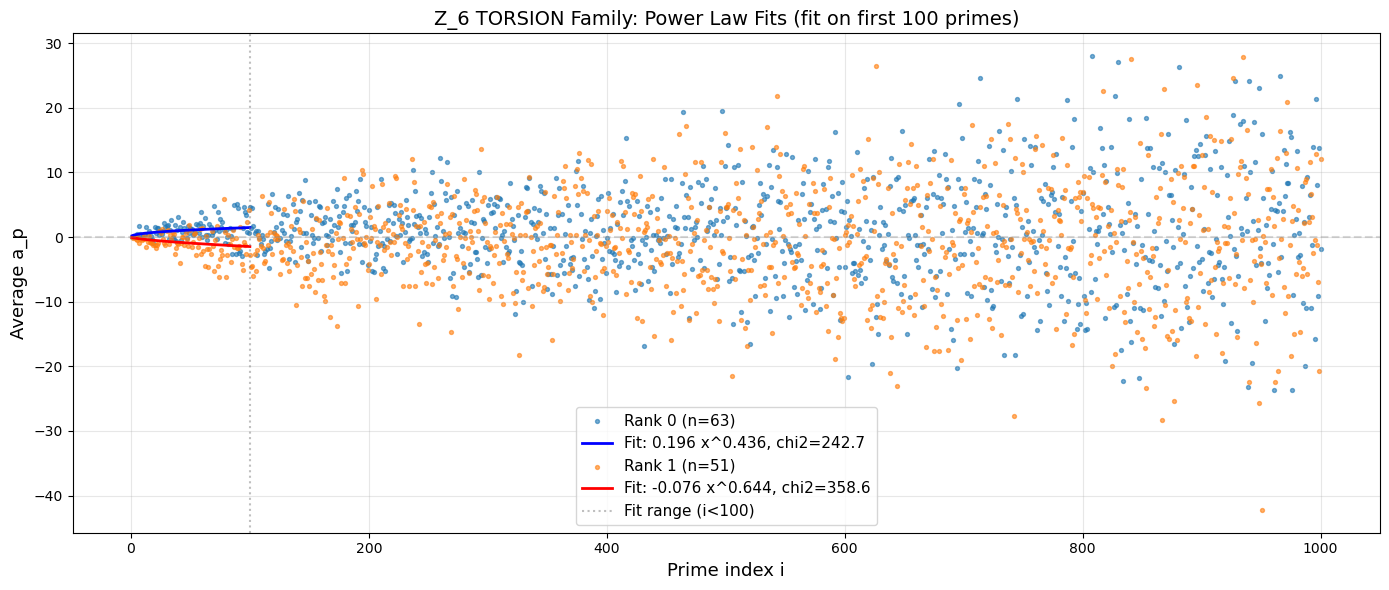

Saved comparison plot to Fast_Murmuration_Search/Z_6_TORSION_vs_random.png


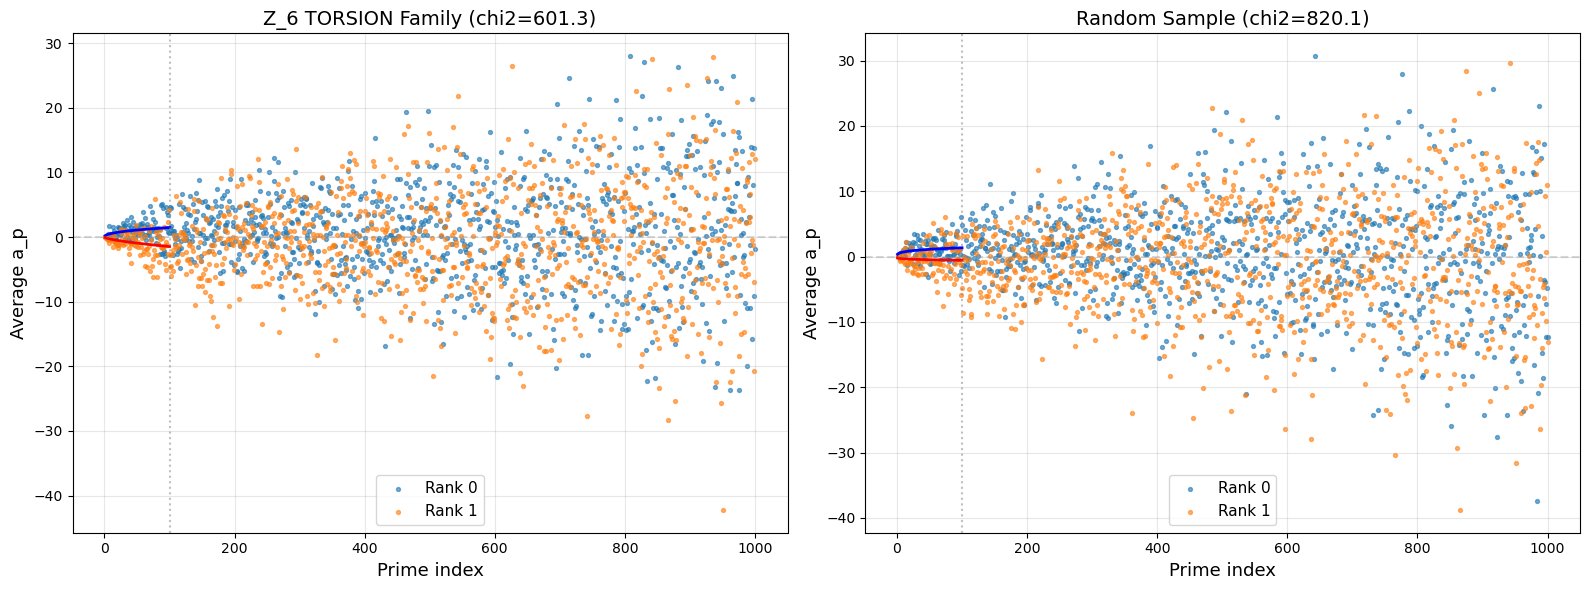


✓ SUCCESS - FINAL SUMMARY
Family: Z_6 TORSION
Curves: 63 rank 0, 51 rank 1
Family chi² = 601.27
Random chi² = 820.10

🎯 Z_6 TORSION is 1.36x cleaner!


In [5]:

# Z_6: u^2 = 48
# a = (1/192)*phi*(3 - 3*phi - 3*phi^2 - phi^3)
#   = (1/192)*(3*phi - 3*phi^2 - 3*phi^3 - phi^4)
# b = (1/110592)*(27 - 54*phi - 27*phi^2 - 36*phi^3 + 117*phi^4 + 90*phi^5 + 11*phi^6)
output_Z6 = run_family_analysis(
    family_name="Z_6 TORSION",
    a_coeffs={4: -12, 3: -36, 2: -36, 1: 36},
    b_coeffs={6: 11, 5: 90, 4: 117, 3: -36, 2: -27, 1: -54, 0: 27},
    phi_range_m=(-20, 21),
    phi_range_n=(-20, 21),
    n_fit=100,
    seed=42
)

Family: Z_2 x Z_2 TORSION
a(φ) = -3*phi^2 + 3*phi - 3
b(φ) = -2*phi^3 + 3*phi^2 + 3*phi - 2

STEP 1: ANALYZING Z_2 x Z_2 TORSION FAMILY

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [01:13<00:00,  6.98it/s]



RESULTS FOR Z_2 x Z_2 TORSION
Total phis tried: 511
Hits (N < 100,000): 323
Misses (N >= 100,000 or singular): 188
Efficiency: 63.2%

Distinct isogeny classes: 300
Redundant hits (same iso class): 23

Multiplicity distribution:
  1x: 283 isogeny classes
  2x: 13 isogeny classes
  3x: 2 isogeny classes
  4x: 2 isogeny classes

Top 10 highest multiplicity isogeny classes:
  72a: 4 phis → [4, 8/9, 1/4, -8]
  144b: 4 phis → [9, 1/9, 3/4, -3]
  45a: 3 phis → [16, -16/9, 1/16]
  720h: 3 phis → [-9/16, 15/16, -15]
  288d: 2 phis → [2, -1]
  720d: 2 phis → [5, -1/4]
  1440e: 2 phis → [10, -1/9]
  2448o: 2 phis → [17, -1/16]
  1008k: 2 phis → [-7/9, 7/16]
  936i: 2 phis → [-4/9, 13/4]

Rank 0: 146 curves
Rank 1: 145 curves

Saved to Fast_Murmuration_Search/Z_2_x_Z_2_TORSION_avg_aps.sobj


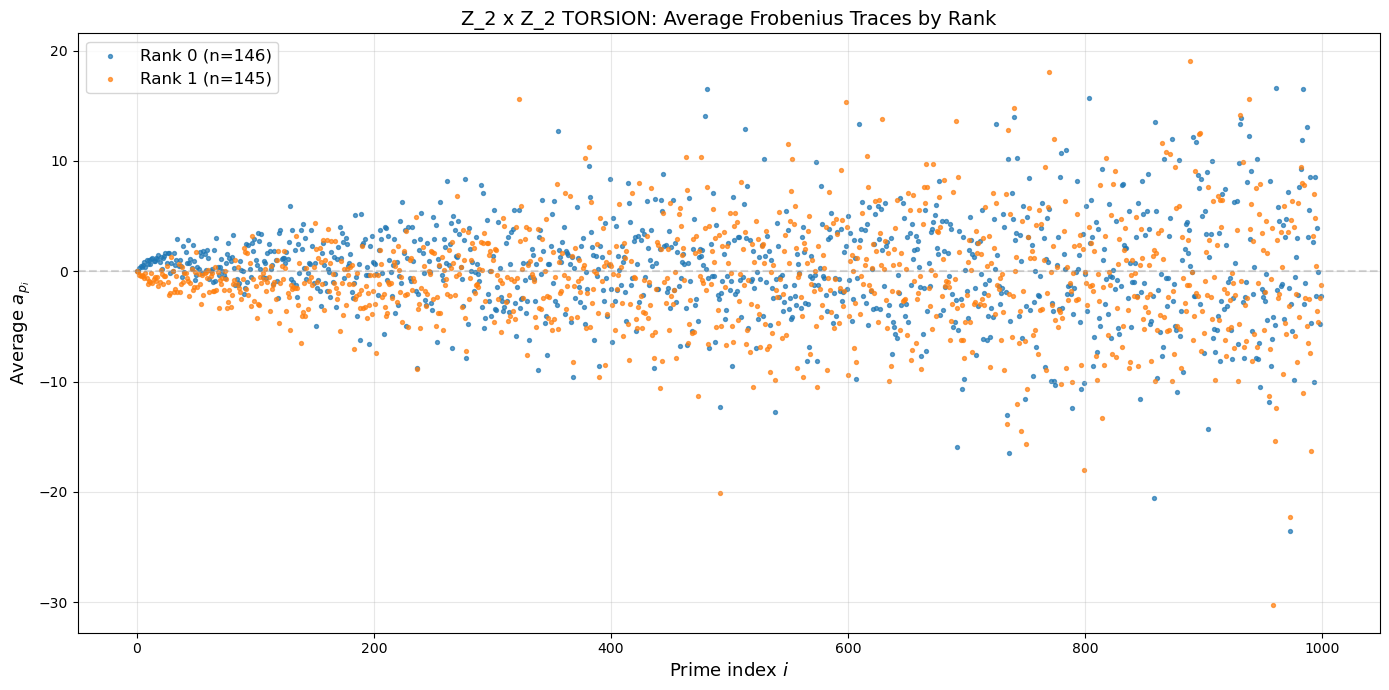

Plot saved to Fast_Murmuration_Search/Z_2_x_Z_2_TORSION_avg_aps.png

STEP 2: COMPARING TO RANDOM SAMPLES
Loading data from Fast_Murmuration_Search/Z_2_x_Z_2_TORSION_avg_aps.sobj...

Z_2 x Z_2 TORSION family: 146 rank 0, 145 rank 1 curves

Fitting first 100 primes for Z_2 x Z_2 TORSION...

Rank 0 fit: 0.8155 * x^-0.0242
  chi2 = 115.62

Rank 1 fit: -0.3653 * x^0.2103
  chi2 = 136.15

Total chi2 for Z_2 x Z_2 TORSION = 251.78

Drawing random sample from database...

Fitting random sample (first 100 primes)...
Random sample rank 0 fit: 0.1593 * x^0.5004, chi2=151.92
Random sample rank 1 fit: -0.0921 * x^0.5408, chi2=156.43
Random total chi2 = 308.35

--- COMPARISON ---
Z_2 x Z_2 TORSION total chi2:     251.78
Random total chi2: 308.35
Z_2 x Z_2 TORSION is 1.22x cleaner than random

Saved power law fit plot to Fast_Murmuration_Search/Z_2_x_Z_2_TORSION_power_law_fit.png


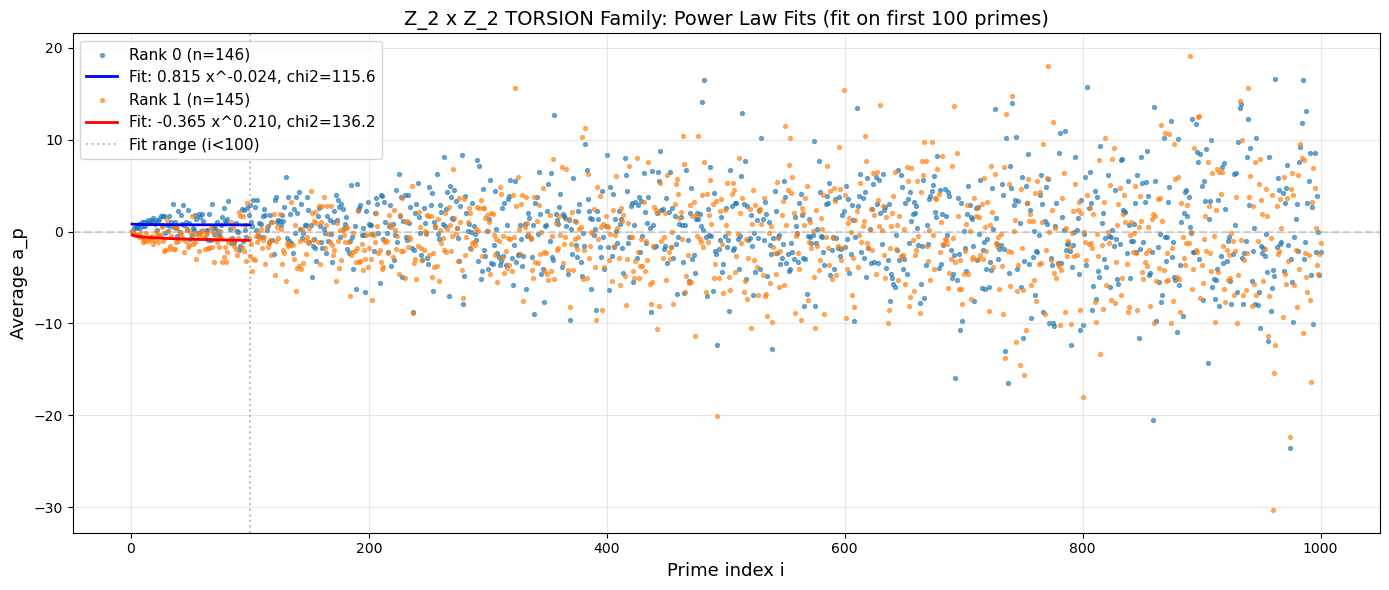

Saved comparison plot to Fast_Murmuration_Search/Z_2_x_Z_2_TORSION_vs_random.png


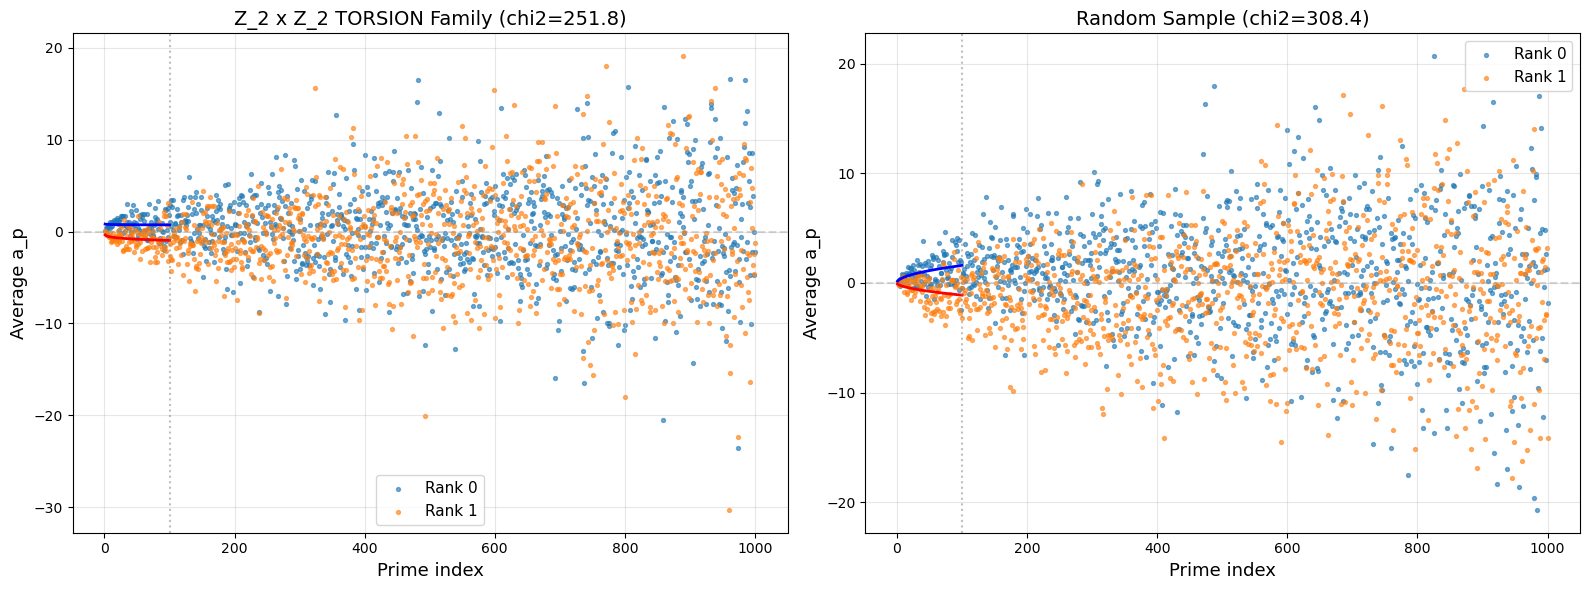


✓ SUCCESS - FINAL SUMMARY
Family: Z_2 x Z_2 TORSION
Curves: 146 rank 0, 145 rank 1
Family chi² = 251.78
Random chi² = 308.35

🎯 Z_2 x Z_2 TORSION is 1.22x cleaner!


In [6]:

# Z_2 x Z_2: u^2 = 3
# a = (1/3)*(phi - 1 - phi^2)
# b = -(1/27)*(1+phi)*(1-2*phi)*(2-phi)
#   = (1/27)*(-2 + 3*phi + 3*phi^2 - 2*phi^3)
output_Z2Z2 = run_family_analysis(
    family_name="Z_2 x Z_2 TORSION",
    a_coeffs={2: -3, 1: 3, 0: -3},
    b_coeffs={3: -2, 2: 3, 1: 3, 0: -2},
    phi_range_m=(-20, 21),
    phi_range_n=(-20, 21),
    n_fit=100,
    seed=42
)

Family: Z_4 x Z_2 TORSION
a(φ) = -768*phi^4 - 672*phi^2 - 3
b(φ) = 8192*phi^6 - 16896*phi^4 - 1056*phi^2 + 2

STEP 1: ANALYZING Z_4 x Z_2 TORSION FAMILY

Generating fraction phis from (-20, 21) / (-20, 21)...
Generated 511 unique phi values
Processing curves...


100%|█████████████████████████████████████████████████████████████████████████████████| 511/511 [00:32<00:00, 15.91it/s]



RESULTS FOR Z_4 x Z_2 TORSION
Total phis tried: 511
Hits (N < 100,000): 192
Misses (N >= 100,000 or singular): 319
Efficiency: 37.6%

Distinct isogeny classes: 77
Redundant hits (same iso class): 115

Multiplicity distribution:
  2x: 62 isogeny classes
  4x: 12 isogeny classes
  6x: 2 isogeny classes
  8x: 1 isogeny classes

Top 10 highest multiplicity isogeny classes:
  720h: 8 phis → [1, -5/16, -1/16, 1/16, 5/16]...
  9360bm: 6 phis → [-1/9, 1/9, -9/16, 9/16, -3/13]...
  45a: 6 phis → [-9/4, 9/4, -5/12, 5/12, -3/20]...
  12240bm: 4 phis → [4, -2/17, 2/17, -4]
  11088v: 4 phis → [-9/8, 9/8, -1/18, 1/18]
  5040i: 4 phis → [-7/8, 7/8, -1/14, 1/14]
  5040m: 4 phis → [-5/8, 5/8, -1/10, 1/10]
  720c: 4 phis → [-3/8, 3/8, -1/6, 1/6]
  144b: 4 phis → [-1/8, 1/8, -1/2, 1/2]
  31824bk: 4 phis → [-13/16, 13/16, -1/13, 1/13]

Rank 0: 41 curves
Rank 1: 34 curves

Saved to Fast_Murmuration_Search/Z_4_x_Z_2_TORSION_avg_aps.sobj


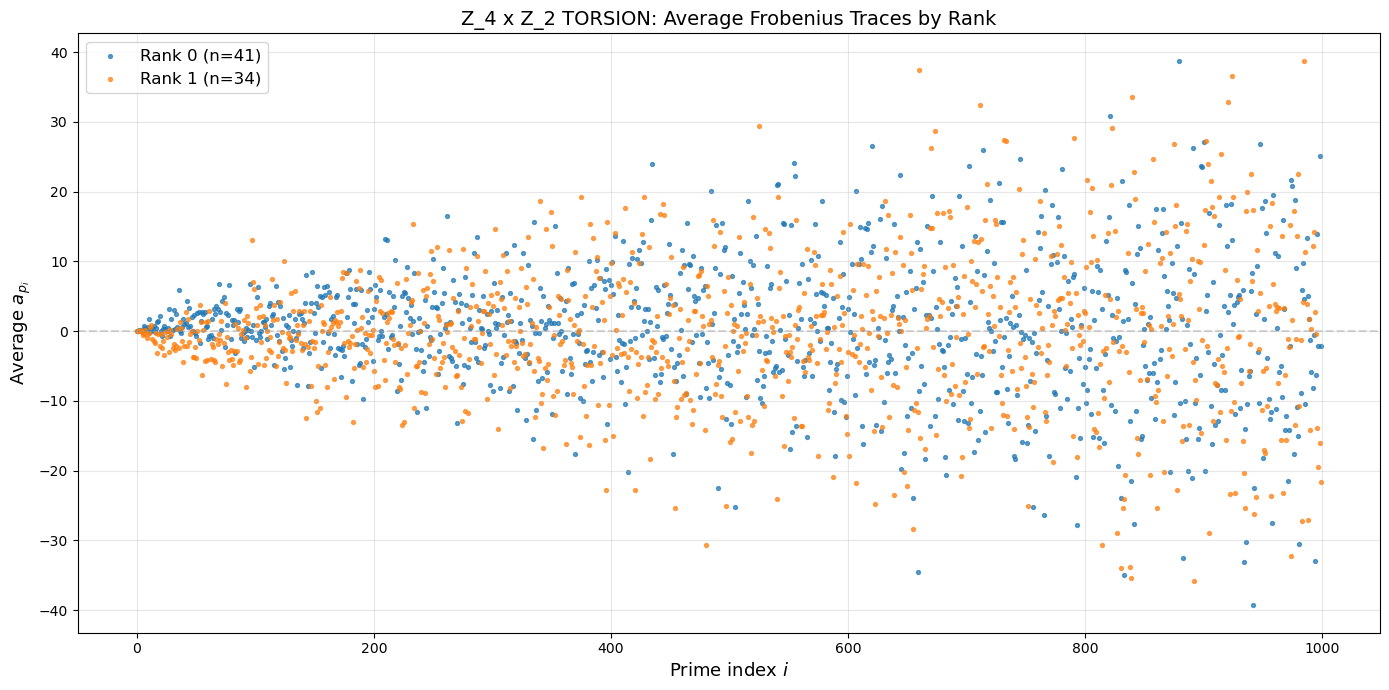

Plot saved to Fast_Murmuration_Search/Z_4_x_Z_2_TORSION_avg_aps.png

STEP 2: COMPARING TO RANDOM SAMPLES
Loading data from Fast_Murmuration_Search/Z_4_x_Z_2_TORSION_avg_aps.sobj...

Z_4 x Z_2 TORSION family: 41 rank 0, 34 rank 1 curves

Fitting first 100 primes for Z_4 x Z_2 TORSION...

Rank 0 fit: 0.4126 * x^0.2610
  chi2 = 367.02

Rank 1 fit: -0.6196 * x^0.1524
  chi2 = 829.53

Total chi2 for Z_4 x Z_2 TORSION = 1196.55

Drawing random sample from database...

Fitting random sample (first 100 primes)...
Random sample rank 0 fit: 0.3095 * x^0.3503, chi2=586.00
Random sample rank 1 fit: -0.0000 * x^8.6766, chi2=517.99
Random total chi2 = 1103.99

--- COMPARISON ---
Z_4 x Z_2 TORSION total chi2:     1196.55
Random total chi2: 1103.99
Z_4 x Z_2 TORSION is 0.92x cleaner than random

Saved power law fit plot to Fast_Murmuration_Search/Z_4_x_Z_2_TORSION_power_law_fit.png


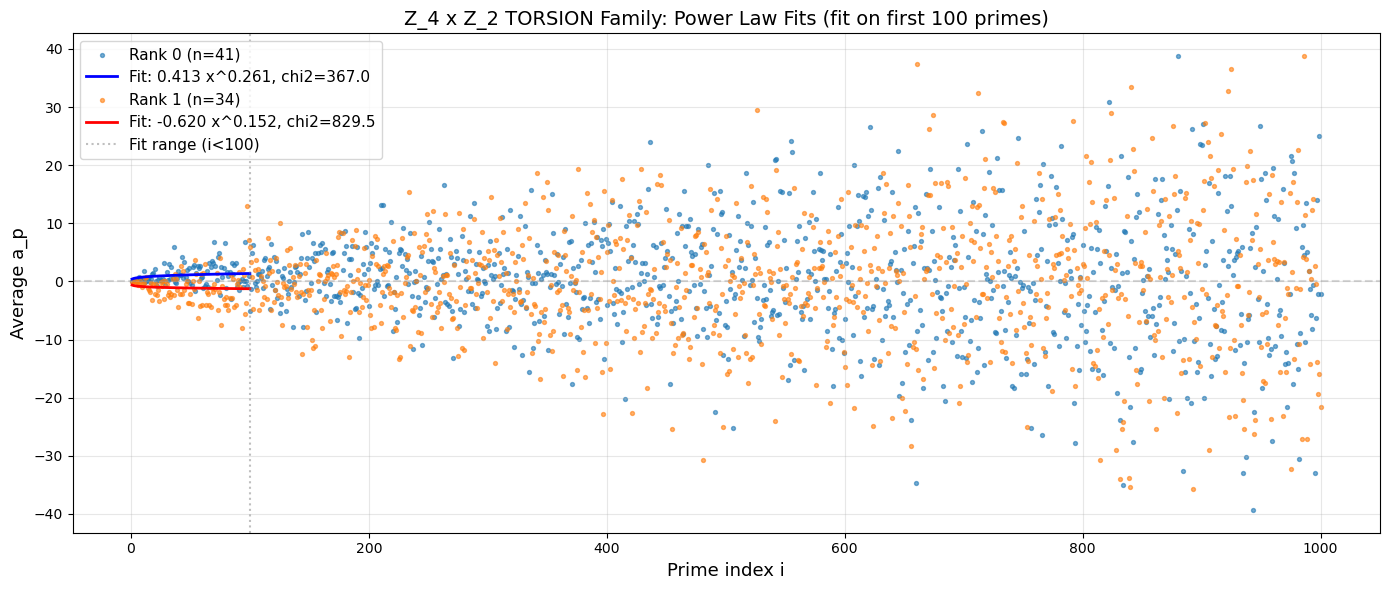

Saved comparison plot to Fast_Murmuration_Search/Z_4_x_Z_2_TORSION_vs_random.png


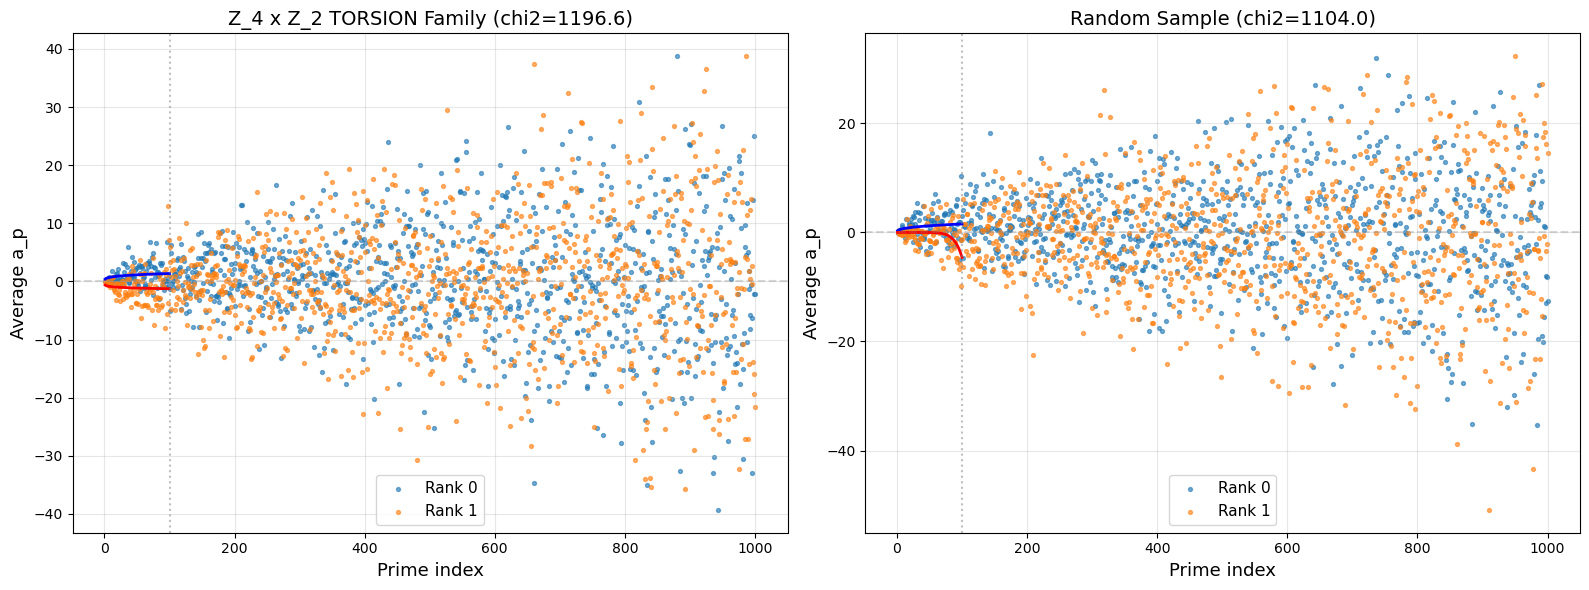


✓ SUCCESS - FINAL SUMMARY
Family: Z_4 x Z_2 TORSION
Curves: 41 rank 0, 34 rank 1
Family chi² = 1196.55
Random chi² = 1103.99

🎯 Z_4 x Z_2 TORSION is 0.92x cleaner!


In [7]:

# Z_4 x Z_2: u^2 = 48
# a = -1/768 - 7*phi^2/24 - phi^4/3
# b = (1/55296)*(1 + 16*phi^2)*(1 - 24*phi + 16*phi^2)*(1 + 24*phi + 16*phi^2)
#   = (1/55296)*(1 - 528*phi^2 - 8448*phi^4 + 4096*phi^6)
output_Z4Z2 = run_family_analysis(
    family_name="Z_4 x Z_2 TORSION",
    a_coeffs={4: -768, 2: -672, 0: -3},
    b_coeffs={6: 8192, 4: -16896, 2: -1056, 0: 2},
    phi_range_m=(-20, 21),
    phi_range_n=(-20, 21),
    n_fit=100,
    seed=42
)

In [1]:
HV_data = load('Fast_Murmuration_Search/HV_avg_aps')

In [3]:
HV_data.keys()

dict_keys(['rk0_avg', 'rk1_avg', 'n0', 'n1', 'family_name', 'a_coeffs', 'b_coeffs'])